# PREDIX HER2 — multimodal pCR prediction: reproducibility notebook

This notebook is the reviewer-facing verification of every number in the revised
manuscript of the PREDIX HER2 multimodal pCR-prediction study. It runs **top to
bottom with no manual steps** from the package root and, at every stage, recomputes
a deposited quantity from the primary artefacts and **asserts equality** with the
deposited tables (tolerance 1e-9 on point estimates and confidence-interval bounds
— all post-processing seeds are fixed, so agreement is exact up to floating point).

**Package layout**

| folder | contents |
|---|---|
| `code/` | the five analysis scripts + `tests/test_statistics.py` + production run scripts |
| `data/` | the canonical PREDIX input file and the two external-cohort files |
| `results/`, `results_rna_ispy2/`, `results_rna_nct/` | the production PKL artefacts (model outputs), CV splits, provenance |
| `report/` | the deposited figures and tables that this notebook reproduces |
| `environment/` | requirements + the production and notebook environments |

**Two reproduction levels**

- **Level A — this notebook (≈ 1–2 h, mostly Sections 5, 7, 12 and 13).** Starting
  from the deposited PKLs in `results/`, every revision table and figure reproduces
  bit-for-bit: all post-processing randomness (bootstraps, permutations) is seeded
  (base seed 20240517 with a deterministic CRC32 offset per quantity). Section 13
  regenerates the *entire* deposited report from the PKLs and compares it cell by cell.
- **Level B — full pipeline re-run (many CPU-hours).** Re-run the model pipeline with
  the exact production command (from `code/production_run_ubuntu.sh`, step 1):

  ```bash
  python multimodal_pcr_pipeline.py \
      --data_path clin_multiomics_curated_metrics_PREDIX_HER2_new.txt \
      --results_dir results --splits_dir results/shared_splits \
      --mode elasticnet --training_data expanded \
      --experiments global dhp tdm1 \
      --classifiers ElasticNet_LR RandomForest ExtraTrees HistGradBoost SVM_Linear \
      --repeats_global 200 --repeats_arm 100 \
      --outer_folds_global 5 --outer_folds_arm 5 \
      --inner_folds_global 5 --inner_folds_arm 3 \
      --univariate_screen in_fold --feature_pool curated \
      --n_jobs <cores> --seed 42 --consensus
  ```

  (steps 2–4 of the same script regenerate the report and the external validation).
  The cross-validation partitions are fully determined by seed 42, but the
  classifier-internal randomness of the tree models is **deliberately unseeded**
  (documented design choice — seeding it would correlate the CV repeats and
  artificially narrow the fold-level variance). A Level B re-run therefore reproduces
  the linear-model numbers exactly and the tree-model numbers statistically; the
  deposited PKLs are the archival record, and Level A verifies everything downstream
  of them bit-for-bit.

**How to run**: open in Jupyter and *Run All*, or headless:
`python run_notebook.py` (requires `nbformat`, `nbclient`, `ipykernel`).
Software: Python ≥ 3.10 and `pip install -r environment/requirements.txt`.

Numbers quoted in the markdown below come from `PRODUCTION_NUMBERS.md` (the
revision's single source of numbers) and the deposited workbooks under
`report/tables/`; every one of them is recomputed and asserted by the code cells.

In [1]:
# ── Setup: imports, paths, helpers ──────────────────────────────────────────
import os, sys, json, time, zlib, pickle, hashlib, subprocess, warnings
from pathlib import Path
T_NOTEBOOK_START = time.time()

PKG = Path.cwd()
assert (PKG / "code").is_dir() and (PKG / "results").is_dir(), (
    "Run this notebook from the package root (the folder containing code/, "
    "data/, results/ and report/).")
sys.path.insert(0, str(PKG / "code"))

warnings.filterwarnings("ignore")            # silence sklearn FutureWarnings etc.
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")                        # before importing the analysis modules
import openpyxl
import pymupdf
from IPython.display import Image, display

import cv_estimands as CE                    # the ONE estimand definition (shared module)
import revision_analyses as RA               # revision statistics (S-groups, DeLong, ...)
import generate_report as GR                 # report generator (imported to prove importability)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)

BOOT_SEED  = 20240517                        # bootstrap seed base (revision_analyses.py)
N_BOOT     = 2000                            # bootstrap resamples
SCENARIOS  = ["Global", "DHP", "T-DM1"]
EXP_MAP    = {"Global": "global", "DHP": "dhp", "T-DM1": "tdm1"}
UNIMODALS  = ["Clin", "RNA", "DNA", "Prot", "WSI"]
FUSED      = "Fused_ElasticNet"
ALL_MODELS = UNIMODALS + [FUSED]

CHECKS = []   # (section, name, passed, detail)

def check(section, name, cond, detail=""):
    cond = bool(cond)
    CHECKS.append((section, name, cond, detail))
    print(f"  [{'PASS' if cond else 'FAIL'}] {name}" + (f"  ({detail})" if detail else ""))
    assert cond, f"CHECK FAILED: section {section} / {name} {detail}"
    return cond

def seed_for(tag):
    # The deterministic bootstrap seed used by revision_analyses.py and
    # generate_report.py: BOOT_SEED + crc32(tag) % 10000.
    return BOOT_SEED + zlib.crc32(tag.encode()) % 10000

def read_sheet(path, sheet, first_header):
    # Read one styled worksheet written by the analysis scripts. Explanatory
    # note rows precede the header; the header row is the first row whose
    # first cell equals `first_header`.
    ws = openpyxl.load_workbook(path, data_only=True)[sheet]
    rows = [[c.value for c in r] for r in ws.iter_rows()]
    hdr_i = next(i for i, r in enumerate(rows) if r and r[0] == first_header)
    hdr = [h for h in rows[hdr_i] if h is not None]
    body = [list(r[:len(hdr)]) + [None] * (len(hdr) - len(r))
            for r in rows[hdr_i + 1:] if any(v is not None for v in r)]
    return pd.DataFrame(body, columns=hdr)

def show_pdf(path, page=0, dpi=110):
    # Render one page of a deposited PDF inline (pymupdf -> PNG).
    doc = pymupdf.open(path)
    png = doc[page].get_pixmap(dpi=dpi).tobytes("png")
    doc.close()
    print(f"[deposited figure] {Path(path).relative_to(PKG).as_posix()}")
    display(Image(data=png))

def close_to(a, b, tol=1e-9):
    if a is None or b is None:
        return a is None and b is None
    a, b = float(a), float(b)
    if np.isnan(a) and np.isnan(b):
        return True
    return abs(a - b) <= tol

print("Package root:", PKG)
print("Setup complete.")

Package root: C:\Users\georg\Documents\claude_kang_multimodal_natcancer\predix-her2-multimodal
Setup complete.


## 1. Environment and provenance

The production pipeline recorded its full configuration, environment and the
SHA-256 of its input file in `results/run_provenance.json`. We verify that this
package carries **exactly** the file the production run was trained on, and print
the canonical cross-validation statement the pipeline generated
(`results/methods_cv_statement.txt` — the Methods text is copied from there,
never hand-written).

In [2]:
print("=" * 78); print("SECTION 1 — Environment and provenance"); print("=" * 78)
import sklearn, scipy
print(f"Python       : {sys.version.split()[0]}  ({sys.platform})")
for m in (np, pd, sklearn, scipy, matplotlib, openpyxl):
    print(f"{m.__name__:13s}: {m.__version__}")

DATA_FILE = PKG / "data" / "clin_multiomics_curated_metrics_PREDIX_HER2_new.txt"
sha = hashlib.sha256(DATA_FILE.read_bytes()).hexdigest()
prov = json.loads((PKG / "results" / "run_provenance.json").read_text(encoding="utf-8-sig"))
print("\nInput file SHA-256 :", sha)
print("Provenance SHA-256 :", prov["input_data"]["sha256"])
check("1", "input-file SHA-256 matches results/run_provenance.json",
      sha == prov["input_data"]["sha256"])
check("1", "SHA-256 equals the published value (7341273d...c629)",
      sha == "7341273da5dfe5555884cd90a695c79cd95aa08a1749270282b826c161cc6629")

print("\n--- production run provenance (results/run_provenance.json) ---")
print(f"pipeline_version : {prov['pipeline_version']}")
print(f"generated_utc    : {prov['generated_utc']}")
print(f"random_seed      : {prov['random_seed']}")
p = prov["parameters"]
for k in ["experiments", "training_data", "repeats_global", "repeats_arm",
          "outer_folds_global", "outer_folds_arm", "inner_folds_global",
          "inner_folds_arm", "univariate_screen", "univ_fdr_q", "univ_max_k",
          "univ_min_k", "feature_pool", "stability_thresh_global",
          "stability_thresh_arm", "corr_threshold", "consensus"]:
    print(f"  {k:24s}: {p[k]}")
print("environment of the production model run:")
for k, v in prov["environment"].items():
    print(f"  {k:13s}: {v}")
print("\nreproducibility_note:")
print(" ", prov["reproducibility_note"])
print("\n--- results/methods_cv_statement.txt ---")
print((PKG / "results" / "methods_cv_statement.txt").read_text(encoding="utf-8-sig"))

SECTION 1 — Environment and provenance
Python       : 3.14.7  (win32)
numpy        : 2.5.2
pandas       : 3.0.5
sklearn      : 1.9.0
scipy        : 1.18.0
matplotlib   : 3.11.1
openpyxl     : 3.1.5

Input file SHA-256 : 7341273da5dfe5555884cd90a695c79cd95aa08a1749270282b826c161cc6629
Provenance SHA-256 : 7341273da5dfe5555884cd90a695c79cd95aa08a1749270282b826c161cc6629
  [PASS] input-file SHA-256 matches results/run_provenance.json
  [PASS] SHA-256 equals the published value (7341273d...c629)

--- production run provenance (results/run_provenance.json) ---
pipeline_version : 2.0.0-revision1
generated_utc    : 2026-08-14T22:45:16+00:00
random_seed      : 42
  experiments             : ['global', 'dhp', 'tdm1']
  training_data           : expanded
  repeats_global          : 200
  repeats_arm             : 100
  outer_folds_global      : 5
  outer_folds_arm         : 5
  inner_folds_global      : 5
  inner_folds_arm         : 3
  univariate_screen       : in_fold
  univ_fdr_q             

## 2. The canonical dataset

One tab-separated file drives everything: 197 patients × 114 columns
(`patientID`, `pCR`, and 112 features prefixed `Clin_` / `RNA_` / `DNA_` /
`Prot_` / `WSI_`). The complete case for the multimodal models is every patient
with complete RNA, DNA, proteomics and WSI (clinical covariates are recorded for
everyone and imputed in-fold, so `Clin_` does not enter the completeness rule —
see `get_complete_case()` in `code/multimodal_pcr_pipeline.py`). Treatment arm is
encoded DHP = 0, T-DM1 = 1; the arm-wise counts verify the coding.

In [3]:
print("=" * 78); print("SECTION 2 — The canonical dataset"); print("=" * 78)
first_line = DATA_FILE.open(encoding="utf-8").readline()
check("2", "file is tab-separated (delimiter check)", first_line.count("\t") == 113,
      f"{first_line.count(chr(9))} tabs in the header line")
df = pd.read_csv(DATA_FILE, sep="\t")
print(f"shape: {df.shape[0]} patients x {df.shape[1]} columns")
check("2", "197 patients x 114 columns", df.shape == (197, 114))

mod_cols = {m: [c for c in df.columns if c.startswith(m + "_")] for m in UNIMODALS}
other = [c for c in df.columns if not any(c.startswith(m + "_") for m in UNIMODALS)]
for m in UNIMODALS:
    print(f"  {m:5s}: {len(mod_cols[m]):3d} feature columns")
print(f"  other: {other}")
check("2", "features per modality = Clin 5 / RNA 43 / DNA 42 / Prot 19 / WSI 3",
      [len(mod_cols[m]) for m in UNIMODALS] == [5, 43, 42, 19, 3])
check("2", "identifier and outcome columns are patientID and pCR",
      other == ["patientID", "pCR"])

molecular = [c for m in ("RNA", "DNA", "Prot", "WSI") for c in mod_cols[m]]
cc = df.dropna(subset=molecular)
arm = df["Clin_Arm"].map({"DHP": 0, "T-DM1": 1})     # the pipeline's encoding
cc_arm = arm.loc[cc.index]
n_dhp,  ev_dhp  = int((cc_arm == 0).sum()), int(cc.loc[cc_arm == 0, "pCR"].sum())
n_tdm1, ev_tdm1 = int((cc_arm == 1).sum()), int(cc.loc[cc_arm == 1, "pCR"].sum())
print(f"\ncomplete case (multimodal models): n={len(cc)}, pCR events={int(cc['pCR'].sum())}")
print(f"  DHP   (Clin_Arm=0): n={n_dhp}, events={ev_dhp}")
print(f"  T-DM1 (Clin_Arm=1): n={n_tdm1}, events={ev_tdm1}")
check("2", "complete case n=109 with 46 pCR events",
      (len(cc), int(cc["pCR"].sum())) == (109, 46))
check("2", "DHP arm (code 0) n=58 / 24 events — confirms DHP=0 coding",
      (n_dhp, ev_dhp) == (58, 24))
check("2", "T-DM1 arm (code 1) n=51 / 22 events", (n_tdm1, ev_tdm1) == (51, 22))

rna_cc = df.dropna(subset=mod_cols["RNA"])
print(f"\nRNA-complete cohort (RNA-only external-validation runs): n={len(rna_cc)}")
check("2", "RNA-complete n=185", len(rna_cc) == 185)

print("\nNOTE: the submitted manuscript states complete case n=110 (DHP 59). The")
print("canonical data delivery yields 109 (DHP 58): one DHP patient lacks complete")
print("molecular data. This is under reconciliation with the data provider; every")
print("revision number is computed on n=109.")

SECTION 2 — The canonical dataset
  [PASS] file is tab-separated (delimiter check)  (113 tabs in the header line)
shape: 197 patients x 114 columns
  [PASS] 197 patients x 114 columns
  Clin :   5 feature columns
  RNA  :  43 feature columns
  DNA  :  42 feature columns
  Prot :  19 feature columns
  WSI  :   3 feature columns
  other: ['patientID', 'pCR']
  [PASS] features per modality = Clin 5 / RNA 43 / DNA 42 / Prot 19 / WSI 3
  [PASS] identifier and outcome columns are patientID and pCR

complete case (multimodal models): n=109, pCR events=46
  DHP   (Clin_Arm=0): n=58, events=24
  T-DM1 (Clin_Arm=1): n=51, events=22
  [PASS] complete case n=109 with 46 pCR events
  [PASS] DHP arm (code 0) n=58 / 24 events — confirms DHP=0 coding
  [PASS] T-DM1 arm (code 1) n=51 / 22 events

RNA-complete cohort (RNA-only external-validation runs): n=185
  [PASS] RNA-complete n=185

NOTE: the submitted manuscript states complete case n=110 (DHP 59). The
canonical data delivery yields 109 (DHP 58): 

## 3. Statistical test suite

`code/tests/test_statistics.py` validates every statistical routine against an
independent reference (scipy, scikit-learn, R's `p.adjust`, hand-computed
Kaplan–Meier), checks the type-I error of the DeLong and interaction tests under
a true null, and **synthetically reproduces the held-out-outcome artefact** that
motivated the estimand correction (Section 6). Exit code 0 means every check passed.

In [4]:
print("=" * 78); print("SECTION 3 — Statistical test suite"); print("=" * 78)
t0 = time.time()
r = subprocess.run([sys.executable, str(Path("code") / "tests" / "test_statistics.py")],
                   capture_output=True, text=True, cwd=str(PKG))
print(f"exit code {r.returncode} after {time.time()-t0:.0f}s; last 15 lines of output:\n")
print("\n".join(r.stdout.strip().splitlines()[-15:]))
if r.returncode != 0:
    print("\nSTDERR (tail):\n", r.stderr[-3000:])
check("3", "test suite exit code 0", r.returncode == 0)
check("3", "'ALL CHECKS PASSED' printed", "ALL CHECKS PASSED" in r.stdout)

SECTION 3 — Statistical test suite


exit code 0 after 14s; last 15 lines of output:

PASS  brier == mean per-repeat Brier  
PASS  ECE small  0.0243
PASS  overconfident -> slope < 0.75 and CI excludes 1  0.426
PASS  reliability rows cover all (repeat, patient) predictions  
PASS  distinct patients per bin <= n  
PASS  bins ordered by predicted risk  
PASS  observed inside its cluster CI in every bin  
PASS  calibrated: observed ~ predicted per bin  max gap 0.067

=== 19j. legacy mean-of-fold metric ===
PASS  mean_fold_metric == mean sklearn per fold  0.559097
PASS  mean-fold and per-repeat estimands differ in general  

ALL CHECKS PASSED
  [PASS] test suite exit code 0
  [PASS] 'ALL CHECKS PASSED' printed


True

## 4. Deposited model artefacts and the cross-validation design

For every scenario (Global / DHP / T-DM1) the pipeline deposited two PKLs:
the **discovery** artefact (per-fold winner signature and classifier, fully
nested) and the **consensus** re-evaluation (frozen consensus signature,
fold-refit weights and fusion, on the same splits). We verify the design directly
from the artefacts: 5-fold × 200 repeats global (1,000 outer folds) and 5-fold ×
100 repeats per arm (500), every repeat complete, and **every patient predicted
exactly once per repeat** — the property the estimand rests on.

In [5]:
print("=" * 78); print("SECTION 4 — PKLs and CV design"); print("=" * 78)
DISC, CONS = {}, {}
for sc in SCENARIOS:
    exp = EXP_MAP[sc]
    with open(PKG / "results" / exp / f"{exp}_elasticnet_results.pkl", "rb") as f:
        DISC[sc] = pickle.load(f)
    with open(PKG / "results" / exp / f"{exp}_consensus_eval.pkl", "rb") as f:
        CONS[sc] = pickle.load(f)

EXPECT = {"Global": dict(folds=1000, repeats=200, n=109, ev=46),
          "DHP":    dict(folds=500,  repeats=100, n=58,  ev=24),
          "T-DM1":  dict(folds=500,  repeats=100, n=51,  ev=22)}

RM, rows = {}, []
for sc in SCENARIOS:
    e = EXPECT[sc]
    n_cons_folds = len(CONS[sc]["folds"])
    for mod in ALL_MODELS:
        n_disc = len(DISC[sc].get(mod, []))
        rm_c = CE.consensus_repeat_matrix(CONS[sc], mod)
        rm_d = CE.discovery_repeat_matrix(DISC[sc][mod])
        RM[(sc, "consensus", mod)] = rm_c
        RM[(sc, "discovery", mod)] = rm_d
        ppp = rm_c.predictions_per_patient()
        rows.append(dict(scenario=sc, model=mod, discovery_folds=n_disc,
                         consensus_folds=n_cons_folds,
                         n_repeats=rm_c.n_repeats,
                         folds_per_repeat=sorted(set(rm_c.folds_per_repeat)),
                         incomplete_repeats=rm_c.incomplete_repeats,
                         n_patients=rm_c.n_patients, n_events=rm_c.n_events,
                         preds_per_patient=f"{ppp.min()}-{ppp.max()}"))
        assert n_disc == e["folds"] and n_cons_folds == e["folds"]
        assert rm_c.n_repeats == e["repeats"] and rm_d.n_repeats == e["repeats"]
        assert set(rm_c.folds_per_repeat) == {5} and set(rm_d.folds_per_repeat) == {5}
        assert rm_c.incomplete_repeats == 0 and rm_d.incomplete_repeats == 0
        assert (ppp == rm_c.n_repeats).all()
        assert (rm_d.predictions_per_patient() == rm_d.n_repeats).all()
        assert (rm_c.n_patients, rm_c.n_events) == (e["n"], e["ev"])
        assert (rm_d.n_patients, rm_d.n_events) == (e["n"], e["ev"])
display(pd.DataFrame(rows))
check("4", "design verified for all 18 (scenario, model) pairs: 5 folds/repeat, "
           "200/100/100 complete repeats, every patient predicted exactly once "
           "per repeat, cohorts 109/58/51 with 46/24/22 events", True)

SECTION 4 — PKLs and CV design


,scenario,model,discovery_folds,consensus_folds,n_repeats,folds_per_repeat,incomplete_repeats,n_patients,n_events,preds_per_patient
0,Global,Clin,1000,1000,200,[5],0,109,46,200-200
1,Global,RNA,1000,1000,200,[5],0,109,46,200-200
2,Global,DNA,1000,1000,200,[5],0,109,46,200-200
3,Global,Prot,1000,1000,200,[5],0,109,46,200-200
4,Global,WSI,1000,1000,200,[5],0,109,46,200-200
5,Global,Fused_ElasticNet,1000,1000,200,[5],0,109,46,200-200
6,DHP,Clin,500,500,100,[5],0,58,24,100-100
7,DHP,RNA,500,500,100,[5],0,58,24,100-100
8,DHP,DNA,500,500,100,[5],0,58,24,100-100
9,DHP,Prot,500,500,100,[5],0,58,24,100-100


  [PASS] design verified for all 18 (scenario, model) pairs: 5 folds/repeat, 200/100/100 complete repeats, every patient predicted exactly once per repeat, cohorts 109/58/51 with 46/24/22 events


True

## 5. Headline performance (revision Table 1)

**Estimand (stated verbatim from the revision):** AUROC/AUPRC/Brier = in each CV
repeat every patient has exactly one out-of-fold prediction; the metric is
computed on that complete out-of-fold vector and averaged over the repeats (200
global / 100 arm). 95% CI = patient-level CLUSTER bootstrap: 2,000 stratified
resamples of PATIENTS, a resampled patient carrying all its repeat predictions.
Predictions are never averaged across repeats or models. Paired Δ: same patient
resample applied to both models and all repeats (primary); DeLong per repeat
summarised (descriptive). Verdict "not distinguishable" whenever the paired 95%
CI includes 0. Previously reported "±" = SD of per-fold AUROC = NOT a CI.

Every quantity is recomputed here from the PKLs with `cv_estimands` and the
deterministic seed `20240517 + crc32("{scenario}|{source}|{model}|{metric}") % 10000`
— the exact seed rule of `revision_analyses.py` and `generate_report.py` — and
asserted against `report/tables/revision/revision_performance_CI.xlsx` and the
Performance sheet of `report/tables/PREDIX_HER2_results.xlsx`.

In [6]:
print("=" * 78); print("SECTION 5 — Headline performance with cluster-bootstrap CIs"); print("=" * 78)
print("Recomputing AUROC/AUPRC/Brier + 95% CI for 36 (scenario, source, model) cells,")
print(f"{N_BOOT} patient-level cluster-bootstrap resamples each ...")
t0 = time.time()
perf_rows = []
for sc in SCENARIOS:
    for source in ("consensus", "discovery"):
        for mod in ALL_MODELS:
            rm = RM[(sc, source, mod)]
            row = dict(scenario=sc, source=source, model=mod,
                       n_patients=rm.n_patients, n_events=rm.n_events,
                       n_cv_repeats=rm.n_repeats)
            for metric in ("AUROC", "AUPRC", "Brier"):
                res = CE.bootstrap_repeat_metric_ci(
                    rm.P, rm.y, metric, n_boot=N_BOOT,
                    seed=seed_for(f"{sc}|{source}|{mod}|{metric}"))
                row[metric] = res["estimate"]
                row[f"{metric}_CI_low"] = res["ci_low"]
                row[f"{metric}_CI_high"] = res["ci_high"]
            if source == "consensus":
                getter = ((lambda f: f["fused_y_pred"]) if mod == FUSED
                          else (lambda f, m=mod: f["unimodal_y_pred"][m]))
                row["AUROC_mean_per_fold"] = CE.mean_fold_metric(CONS[sc]["folds"], getter, "AUROC")
            else:
                row["AUROC_mean_per_fold"] = CE.mean_fold_metric(
                    DISC[sc][mod], lambda f: f["y_pred"], "AUROC")
            perf_rows.append(row)
PERF = pd.DataFrame(perf_rows)
print(f"done in {(time.time()-t0)/60:.1f} min\n")

hp = PERF[PERF.source == "consensus"].copy()
hp["AUROC (95% CI)"] = hp.apply(
    lambda r: f"{r.AUROC:.3f} ({r.AUROC_CI_low:.3f}-{r.AUROC_CI_high:.3f})", axis=1)
print("Headline table — consensus models, AUROC (95% patient-cluster-bootstrap CI):")
display(hp.pivot(index="model", columns="scenario",
                 values="AUROC (95% CI)").reindex(ALL_MODELS)[SCENARIOS])
print("\nFull recomputed table (both sources; AUPRC / Brier / continuity column included):")
display(PERF.round(4))

SECTION 5 — Headline performance with cluster-bootstrap CIs
Recomputing AUROC/AUPRC/Brier + 95% CI for 36 (scenario, source, model) cells,
2000 patient-level cluster-bootstrap resamples each ...


done in 2.1 min

Headline table — consensus models, AUROC (95% patient-cluster-bootstrap CI):


scenario,Global,DHP,T-DM1
model,,,
Clin,0.609 (0.509-0.700),0.568 (0.445-0.696),0.583 (0.472-0.688)
RNA,0.785 (0.701-0.861),0.793 (0.674-0.895),0.808 (0.688-0.914)
DNA,0.519 (0.448-0.585),0.644 (0.534-0.751),0.617 (0.512-0.718)
Prot,0.752 (0.660-0.836),0.777 (0.663-0.878),0.689 (0.550-0.816)
WSI,0.595 (0.485-0.701),0.621 (0.493-0.746),0.541 (0.429-0.648)
Fused_ElasticNet,0.784 (0.710-0.858),0.778 (0.667-0.877),0.771 (0.658-0.870)



Full recomputed table (both sources; AUPRC / Brier / continuity column included):


,scenario,source,model,n_patients,n_events,n_cv_repeats,AUROC,AUROC_CI_low,AUROC_CI_high,AUPRC,AUPRC_CI_low,AUPRC_CI_high,Brier,Brier_CI_low,Brier_CI_high,AUROC_mean_per_fold
0,Global,consensus,Clin,109,46,200,0.6085,0.5094,0.6995,0.5306,0.4560,0.6373,0.2262,0.1994,0.2542,0.6429
1,Global,consensus,RNA,109,46,200,0.7846,0.7008,0.8605,0.7581,0.6688,0.8486,0.1829,0.1502,0.2169,0.7954
2,Global,consensus,DNA,109,46,200,0.5188,0.4481,0.5846,0.4521,0.4116,0.5273,0.2472,0.2397,0.2552,0.5266
3,Global,consensus,Prot,109,46,200,0.7517,0.6604,0.8363,0.6539,0.5667,0.7751,0.1983,0.1664,0.2332,0.7673
4,Global,consensus,WSI,109,46,200,0.5951,0.4854,0.7009,0.5711,0.4796,0.6791,0.2372,0.2193,0.2571,0.6134
5,Global,consensus,Fused_ElasticNet,109,46,200,0.7844,0.7101,0.8577,0.7358,0.6506,0.8336,0.1862,0.1590,0.2160,0.8015
6,Global,discovery,Clin,109,46,200,0.6047,0.5129,0.6998,0.5262,0.4544,0.6424,0.2268,0.1995,0.2562,0.6377
7,Global,discovery,RNA,109,46,200,0.7590,0.6751,0.8398,0.7122,0.6188,0.8158,0.1967,0.1626,0.2344,0.7700
8,Global,discovery,DNA,109,46,200,0.5218,0.4559,0.5887,0.4545,0.4174,0.5223,0.2517,0.2404,0.2628,0.5342
9,Global,discovery,Prot,109,46,200,0.6941,0.6062,0.7758,0.5809,0.5085,0.6905,0.2204,0.1897,0.2536,0.7062


  [PASS] revision_performance_CI.xlsx reproduced (360 values, tol 1e-9)
  [PASS] PREDIX_HER2_results.xlsx Performance sheet: consensus AUROC agrees to 4 decimals (18 cells)
[deposited figure] report/figures/fig01_consensus_performance.pdf


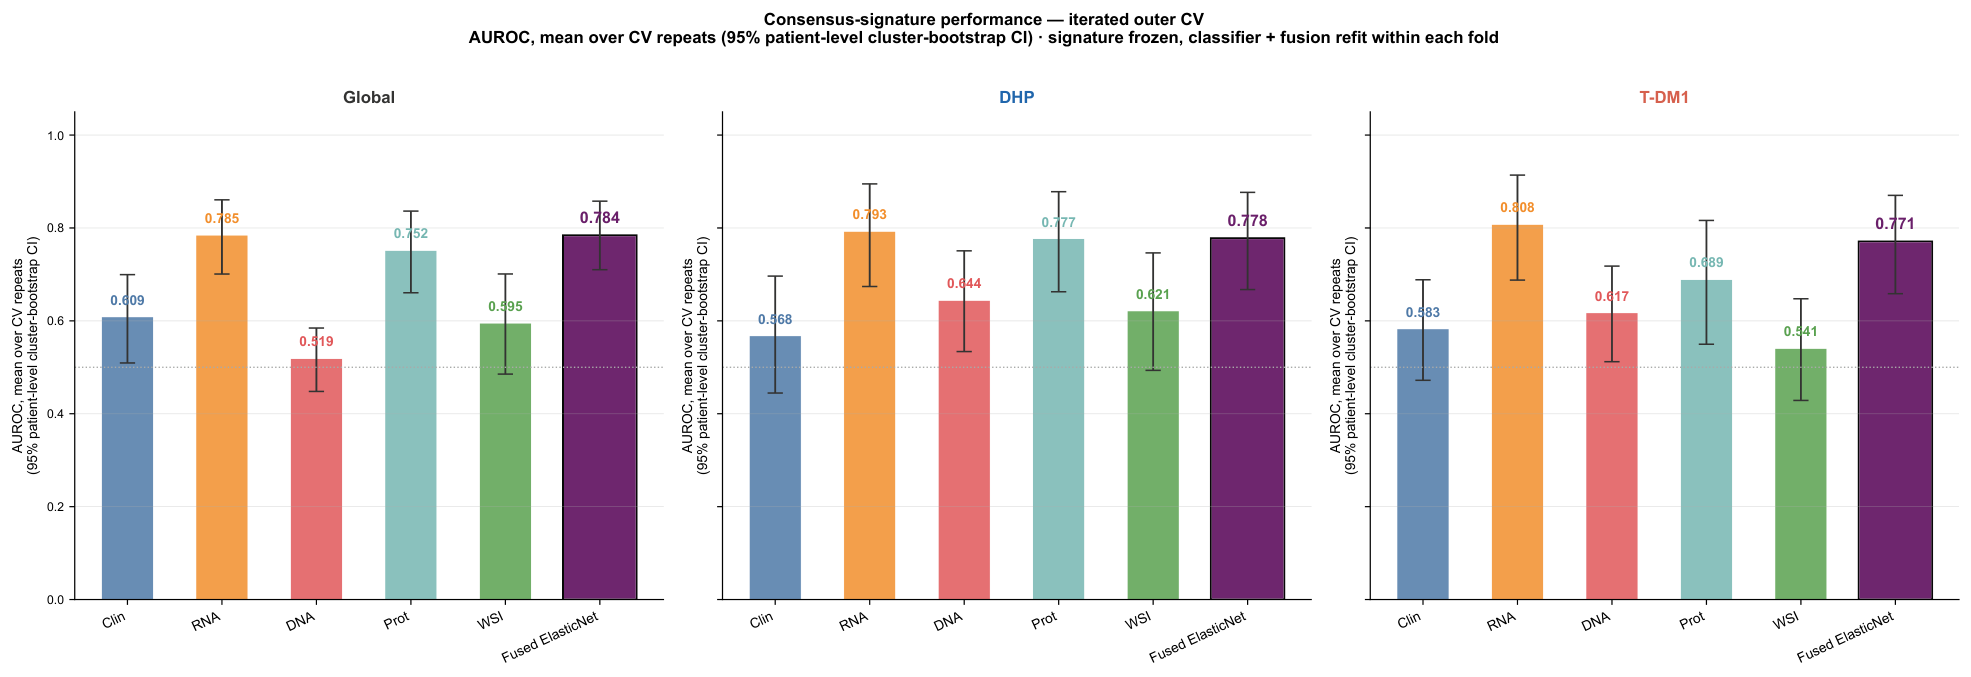

In [7]:
# ── Assert equality with the deposited workbooks ────────────────────────────
wb_perf = read_sheet(PKG / "report/tables/revision/revision_performance_CI.xlsx",
                     "Performance_patient_CI", "scenario").set_index(
                     ["scenario", "source", "model"])
num_cols = ["AUROC", "AUROC_CI_low", "AUROC_CI_high",
            "AUPRC", "AUPRC_CI_low", "AUPRC_CI_high",
            "Brier", "Brier_CI_low", "Brier_CI_high"]
n_cmp = n_bad = 0
for _, r in PERF.iterrows():
    w = wb_perf.loc[(r.scenario, r.source, r.model)]
    for c in num_cols:
        n_cmp += 1
        if not close_to(r[c], w[c]):
            n_bad += 1
            print(f"MISMATCH {r.scenario}/{r.source}/{r.model} {c}: {r[c]!r} vs {w[c]!r}")
    n_cmp += 1
    if not close_to(r["AUROC_mean_per_fold"],
                    w["AUROC_mean_per_fold_(original_estimand,_no_CI)"]):
        n_bad += 1
        print(f"MISMATCH continuity column {r.scenario}/{r.source}/{r.model}")
    assert (int(w["n_patients"]), int(w["n_events"]), int(w["n_cv_repeats"])) == \
           (r.n_patients, r.n_events, r.n_cv_repeats)
check("5", f"revision_performance_CI.xlsx reproduced ({n_cmp} values, tol 1e-9)", n_bad == 0)

wb_main = read_sheet(PKG / "report/tables/PREDIX_HER2_results.xlsx",
                     "Performance", "Scenario").set_index(["Scenario", "Model"])
n_bad = 0
for _, r in PERF[PERF.source == "consensus"].iterrows():
    v = wb_main.loc[(r.scenario, r.model), "AUROC (mean over CV repeats)"]
    if not close_to(round(float(r["AUROC"]), 4), float(v), tol=1e-12):
        n_bad += 1
        print("MISMATCH", r.scenario, r.model, r["AUROC"], v)
check("5", "PREDIX_HER2_results.xlsx Performance sheet: consensus AUROC agrees "
           "to 4 decimals (18 cells)", n_bad == 0)

show_pdf(PKG / "report/figures/fig01_consensus_performance.pdf")

## 6. Why this estimand

Three candidate summaries of the same out-of-fold predictions are printed below
for the Global consensus clinical and fused models:

- **(a)** the estimand used everywhere: per-repeat AUROC averaged over the 200 repeats;
- **(b)** the AUROC of each patient's *mean* probability across the 200 repeats;
- **(c)** the mean of per-fold AUROCs (the original submission's estimand, no CI).

**(b) is not used anywhere and is shown only to document why.** Averaging a
patient's 200 probabilities scores a 200-model *ensemble*, and it carries a
systematic held-out-outcome artefact: the fold that holds out a pCR patient was
trained on one fewer event, so that patient's prediction sits a hair lower in
every one of its 200 repeats; averaging removes the noise and only that shift
survives. For the near-uninformative clinical model this drives the AUROC from
≈0.61 to ≈0.41 — a point estimate outside its own confidence interval, purely an
artefact (reproduced synthetically by `tests/test_statistics.py`, Section 19).
For models with signal, (b) is instead mildly *optimistic* (bagging). The
per-repeat estimand (a) is a single-model quantity and suffers neither defect;
(c) is close to (a) up to between-fold calibration heterogeneity but its "±" SD
across folds was never a confidence interval.

In [8]:
print("=" * 78); print("SECTION 6 — Estimand comparison on the production artefacts"); print("=" * 78)
from sklearn.metrics import roc_auc_score
for mod in ("Clin", FUSED):
    rm = RM[("Global", "consensus", mod)]
    a = CE.repeat_mean_metric(rm.P, rm.y, "AUROC")
    b = roc_auc_score(rm.y, np.nanmean(rm.P, axis=0))
    getter = ((lambda f: f["fused_y_pred"]) if mod == FUSED
              else (lambda f: f["unimodal_y_pred"]["Clin"]))
    c = CE.mean_fold_metric(CONS["Global"]["folds"], getter, "AUROC")
    print(f"\nGlobal consensus {mod}:")
    print(f"  (a) per-repeat AUROC averaged over 200 repeats (THE estimand) : {a:.4f}")
    print(f"  (b) AUROC of each patient's mean probability (ensemble; NOT used): {b:.4f}")
    print(f"  (c) mean of per-fold AUROC (submission's estimand, no CI)     : {c:.4f}")
    if mod == "Clin":
        check("6", "held-out-outcome artefact visible: ensemble estimand (b) collapses "
                   f"far below the per-repeat estimand (a) for the clinical model",
              b < a - 0.15, f"(a)={a:.3f} vs (b)={b:.3f}")

SECTION 6 — Estimand comparison on the production artefacts



Global consensus Clin:
  (a) per-repeat AUROC averaged over 200 repeats (THE estimand) : 0.6085
  (b) AUROC of each patient's mean probability (ensemble; NOT used): 0.4141
  (c) mean of per-fold AUROC (submission's estimand, no CI)     : 0.6429
  [PASS] held-out-outcome artefact visible: ensemble estimand (b) collapses far below the per-repeat estimand (a) for the clinical model  ((a)=0.609 vs (b)=0.414)



Global consensus Fused_ElasticNet:
  (a) per-repeat AUROC averaged over 200 repeats (THE estimand) : 0.7844
  (b) AUROC of each patient's mean probability (ensemble; NOT used): 0.8102
  (c) mean of per-fold AUROC (submission's estimand, no CI)     : 0.8015


## 7. Paired model comparisons (fused vs each unimodal model)

All models are evaluated on the same patients and the same CV repeats, so every
comparison is paired. Primary test: **paired patient-level cluster bootstrap** of
Δ = mean-over-repeats AUROC(fused) − AUROC(comparator), the same patient resample
applied to both models and all repeats (seed `20240517 + crc32("cmp|{scenario}|{source}") % 10000`,
one seed per scenario × source, exactly as `revision_analyses.py`). Secondary,
descriptive: DeLong's test once per repeat, summarised. Verdict "not
distinguishable" whenever the 95% interval includes zero. Asserted against
`revision_model_comparisons.xlsx`, sheet `Model_comparisons` (both sources).

In [9]:
print("=" * 78); print("SECTION 7 — Paired comparisons"); print("=" * 78)
t0 = time.time()
cmp_rows = []
for sc in SCENARIOS:
    for source in ("consensus", "discovery"):
        rm_f = RM[(sc, source, FUSED)]
        for mod in ALL_MODELS:      # paired comparisons require identical patients
            assert np.array_equal(RM[(sc, source, mod)].pids, rm_f.pids), \
                f"{sc}/{source}/{mod}: patient sets differ"
        seed = seed_for(f"cmp|{sc}|{source}")
        batch = []
        for mod in UNIMODALS:
            P_alt = RM[(sc, source, mod)].P
            bs = CE.paired_bootstrap_repeat_delta(rm_f.P, P_alt, rm_f.y, "AUROC",
                                                  n_boot=N_BOOT, seed=seed)
            dl = CE.per_repeat_test_summary(rm_f.P, P_alt, rm_f.y, RA.delong_test)
            crosses = (not np.isfinite(bs["ci_low"])
                       or (bs["ci_low"] <= 0 <= bs["ci_high"]))
            verdict = ("not distinguishable" if crosses
                       else (f"{FUSED} higher" if bs["delta"] > 0 else f"{mod} higher"))
            batch.append(dict(scenario=sc, source=source, comparator=mod,
                              AUROC_fused=bs["estimate_1"],
                              AUROC_comparator=bs["estimate_2"],
                              delta=bs["delta"], ci_low=bs["ci_low"],
                              ci_high=bs["ci_high"], p_bootstrap=bs["p_value"],
                              DeLong_p_median=dl["p_median"],
                              DeLong_frac_below_05=dl["frac_p_below_0.05"],
                              verdict=verdict))
        q = RA.benjamini_hochberg(np.array([b["p_bootstrap"] for b in batch]))
        for b, qv in zip(batch, q):
            b["q_BH"] = qv
        cmp_rows += batch
CMP = pd.DataFrame(cmp_rows)
print(f"done in {(time.time()-t0)/60:.1f} min\n")
display(CMP.round(4))

SECTION 7 — Paired comparisons


done in 1.5 min



,scenario,source,comparator,AUROC_fused,AUROC_comparator,delta,ci_low,ci_high,p_bootstrap,DeLong_p_median,DeLong_frac_below_05,verdict,q_BH
0,Global,consensus,Clin,0.7844,0.6085,0.1759,0.0707,0.2741,0.0010,0.0039,0.965,Fused_ElasticNet higher,0.0025
1,Global,consensus,RNA,0.7844,0.7846,-0.0002,-0.0356,0.0374,0.9900,0.5504,0.000,not distinguishable,0.9900
2,Global,consensus,DNA,0.7844,0.5188,0.2656,0.1654,0.3670,0.0005,0.0002,1.000,Fused_ElasticNet higher,0.0025
3,Global,consensus,Prot,0.7844,0.7517,0.0327,-0.0307,0.0965,0.2920,0.3350,0.020,not distinguishable,0.3650
4,Global,consensus,WSI,0.7844,0.5951,0.1893,0.0600,0.3151,0.0060,0.0046,0.975,Fused_ElasticNet higher,0.0100
5,Global,discovery,Clin,0.7497,0.6047,0.1450,0.0439,0.2430,0.0060,0.0204,0.730,Fused_ElasticNet higher,0.0100
6,Global,discovery,RNA,0.7497,0.7590,-0.0093,-0.0424,0.0248,0.5900,0.5703,0.030,not distinguishable,0.5900
7,Global,discovery,DNA,0.7497,0.5218,0.2279,0.1354,0.3173,0.0005,0.0007,0.975,Fused_ElasticNet higher,0.0025
8,Global,discovery,Prot,0.7497,0.6941,0.0556,-0.0099,0.1218,0.0980,0.1909,0.190,not distinguishable,0.1225
9,Global,discovery,WSI,0.7497,0.5694,0.1803,0.0669,0.2928,0.0010,0.0077,0.845,Fused_ElasticNet higher,0.0025


  [PASS] revision_model_comparisons.xlsx reproduced (300 values incl. verdicts, tol 1e-9)

Key reading: fused vs best unimodal (RNA) — not distinguishable in every scenario;
fused vs Clin/DNA — fused higher (Global, DHP, T-DM1 except Clin-discovery-T-DM1).
[deposited figure] report/figures/revision/revfig07_model_comparisons.pdf


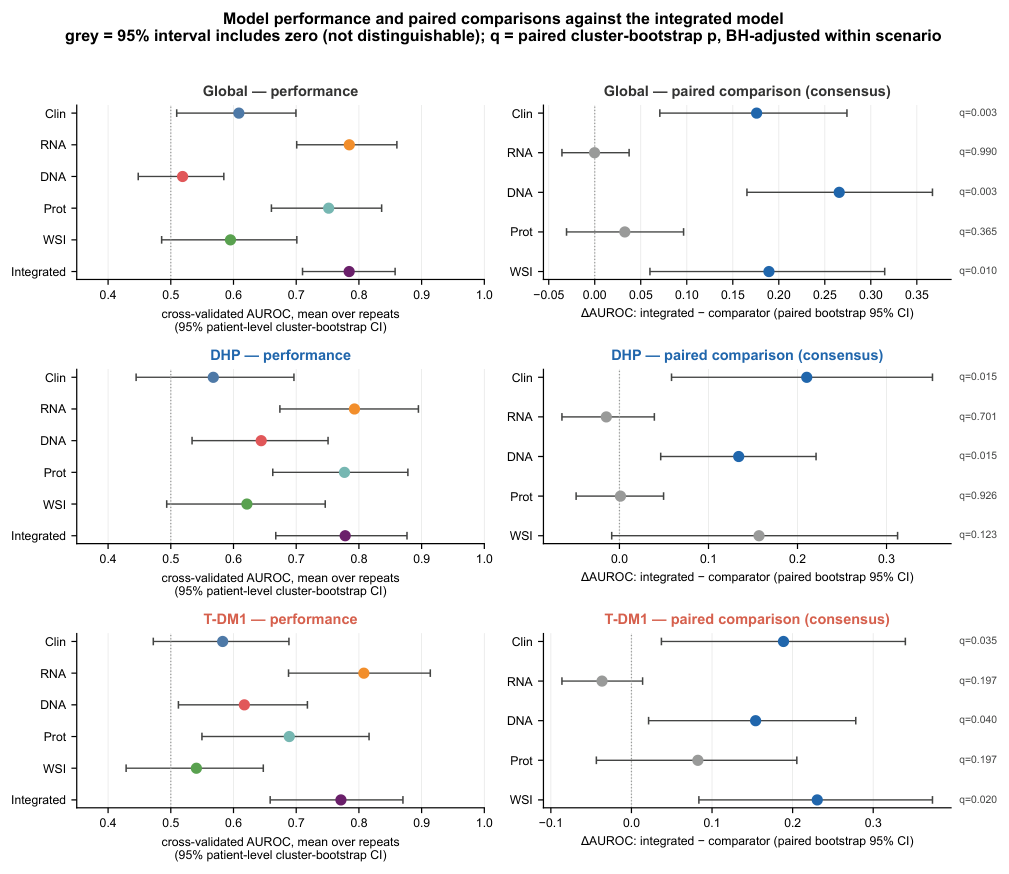

In [10]:
# ── Assert equality with revision_model_comparisons.xlsx ────────────────────
wb_cmp = read_sheet(PKG / "report/tables/revision/revision_model_comparisons.xlsx",
                    "Model_comparisons", "scenario").set_index(
                    ["scenario", "source", "comparator"])
pairs = [("AUROC_fused", "AUROC_reference"), ("AUROC_comparator", "AUROC_comparator"),
         ("delta", "delta_AUROC"), ("ci_low", "delta_CI_low"),
         ("ci_high", "delta_CI_high"), ("p_bootstrap", "p_bootstrap"),
         ("q_BH", "q_bootstrap_BH"), ("DeLong_p_median", "DeLong_p_median_over_repeats"),
         ("DeLong_frac_below_05", "DeLong_frac_repeats_p<0.05")]
n_cmp = n_bad = 0
for _, r in CMP.iterrows():
    w = wb_cmp.loc[(r.scenario, r.source, r.comparator)]
    for mine, dep in pairs:
        n_cmp += 1
        if not close_to(r[mine], w[dep]):
            n_bad += 1
            print(f"MISMATCH {r.scenario}/{r.source}/{r.comparator} {mine}: "
                  f"{r[mine]!r} vs {w[dep]!r}")
    n_cmp += 1
    if r["verdict"] != w["verdict"]:
        n_bad += 1
        print(f"VERDICT MISMATCH {r.scenario}/{r.source}/{r.comparator}: "
              f"{r['verdict']!r} vs {w['verdict']!r}")
check("7", f"revision_model_comparisons.xlsx reproduced ({n_cmp} values incl. "
           f"verdicts, tol 1e-9)", n_bad == 0)
print("\nKey reading: fused vs best unimodal (RNA) — not distinguishable in every "
      "scenario;\nfused vs Clin/DNA — fused higher (Global, DHP, T-DM1 except "
      "Clin-discovery-T-DM1).")
show_pdf(PKG / "report/figures/revision/revfig07_model_comparisons.pdf")

## 8. Calibration of the consensus fused model

Calibration slope and intercept from `logit P(pCR) = a + b·logit(p)` fitted on each
repeat's complete out-of-fold vector and averaged over repeats; Brier and ECE
likewise; CIs from the same patient-level cluster bootstrap (seed
`20240517 + crc32("cal|{scenario}|consensus") % 10000`). Slope ≥ 1 = probabilities
slightly compressed, not overconfident (they are Platt-recalibrated inside the CV).
Asserted against `revision_calibration.xlsx`, sheet `Calibration_summary`.

SECTION 8 — Calibration


recomputed in 10s



,scenario,n,n_events,slope,slope_lo,slope_hi,intercept,int_lo,int_hi,brier,brier_lo,brier_hi,ece,observed,mean_pred
0,Global,109,46,1.1637,0.8001,1.6913,0.0861,-0.1221,0.3780,0.1862,0.1579,0.2162,0.0985,0.4220,0.4150
1,DHP,58,24,1.4865,0.8555,2.7147,0.1350,-0.1551,0.6976,0.1914,0.1591,0.2261,0.1329,0.4138,0.4117
2,T-DM1,51,22,1.2093,0.7369,2.6612,0.1521,-0.0622,0.7581,0.1980,0.1636,0.2355,0.1233,0.4314,0.4159


  [PASS] revision_calibration.xlsx Calibration_summary reproduced (36 values, tol 1e-9)
[deposited figure] report/figures/revision/revfig01_calibration.pdf


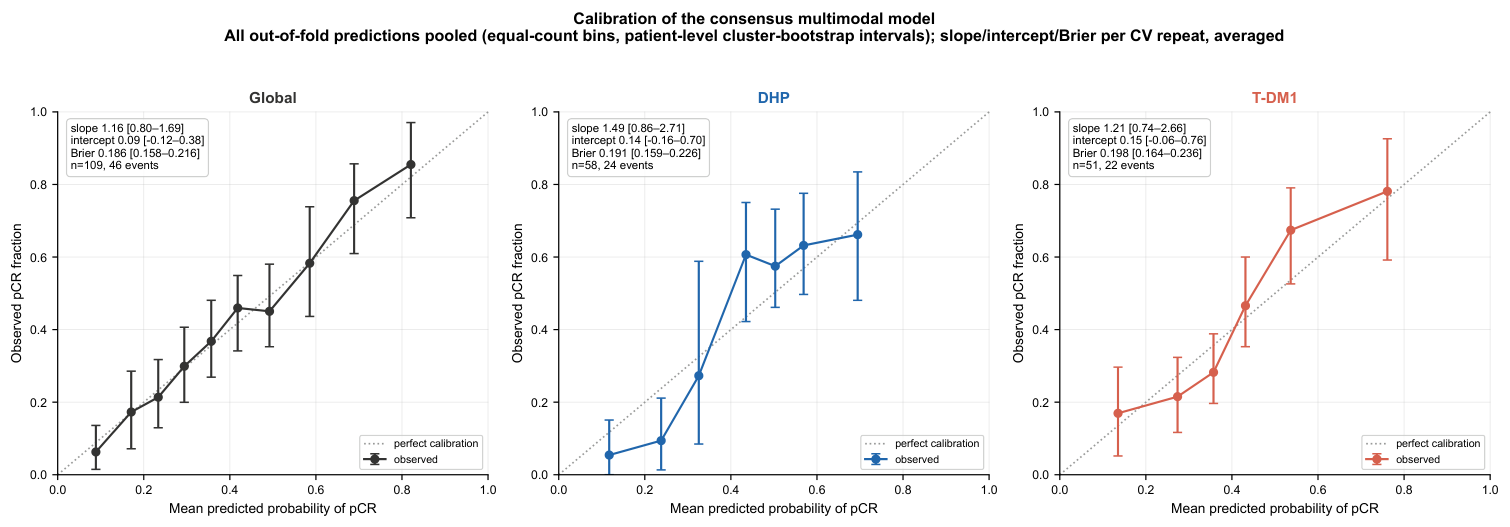

In [11]:
print("=" * 78); print("SECTION 8 — Calibration"); print("=" * 78)
t0 = time.time()
cal_rows = []
for sc in SCENARIOS:
    rm = RM[(sc, "consensus", FUSED)]
    cal = CE.calibration_repeat_summary(rm.P, rm.y, n_boot=N_BOOT,
                                        seed=seed_for(f"cal|{sc}|consensus"),
                                        n_bins=10)
    cal_rows.append(dict(scenario=sc, n=cal["n"], n_events=cal["n_events"],
                         slope=cal["slope"], slope_lo=cal["slope_ci"][0],
                         slope_hi=cal["slope_ci"][1],
                         intercept=cal["intercept"], int_lo=cal["intercept_ci"][0],
                         int_hi=cal["intercept_ci"][1],
                         brier=cal["brier"], brier_lo=cal["brier_ci"][0],
                         brier_hi=cal["brier_ci"][1], ece=cal["ece"],
                         observed=cal["observed_rate"], mean_pred=cal["mean_predicted"]))
CAL = pd.DataFrame(cal_rows)
print(f"recomputed in {time.time()-t0:.0f}s\n")
display(CAL.round(4))

wb_cal = read_sheet(PKG / "report/tables/revision/revision_calibration.xlsx",
                    "Calibration_summary", "scenario").set_index("scenario")
pairs = [("slope", "calibration_slope"), ("slope_lo", "slope_CI_low"),
         ("slope_hi", "slope_CI_high"), ("intercept", "calibration_intercept"),
         ("int_lo", "intercept_CI_low"), ("int_hi", "intercept_CI_high"),
         ("brier", "brier"), ("brier_lo", "brier_CI_low"),
         ("brier_hi", "brier_CI_high"), ("ece", "ECE"),
         ("observed", "observed_pCR_rate"), ("mean_pred", "mean_predicted")]
n_cmp = n_bad = 0
for _, r in CAL.iterrows():
    w = wb_cal.loc[r.scenario]
    for mine, dep in pairs:
        n_cmp += 1
        if not close_to(r[mine], w[dep]):
            n_bad += 1
            print(f"MISMATCH {r.scenario} {mine}: {r[mine]!r} vs {w[dep]!r}")
check("8", f"revision_calibration.xlsx Calibration_summary reproduced "
           f"({n_cmp} values, tol 1e-9)", n_bad == 0)
show_pdf(PKG / "report/figures/revision/revfig01_calibration.pdf")

## 9. Feature-selection stability, fusion weights, events-per-variable

Deposited in `revision_stability.xlsx` (selection frequency across outer folds
with Wilson CIs; fold-wise fusion-weight stability) and `revision_epv_per_fold.xlsx`
(per-fold events and realised EPV). Displayed below, with one recomputation from
the PKLs for each deliverable:

1. selection frequency of `RNA_HER2DX_HER2_amplicon` in the 1,000 Global RNA
   discovery folds (`RA.selection_frequency`, pre-specified threshold 0.60);
2. the Global fusion-layer selection rate for RNA from the consensus folds'
   modality weights (Fusion sheet of `PREDIX_HER2_results.xlsx`);
3. the median number of test-fold pCR events in the Global design (EPV workbook).

SECTION 9 — Stability, fusion weights, EPV
Feature_selection_stability: 181 rows. Stable features per scenario x modality (pre-specified thresholds Global 0.60 / arms 0.50):


modality,Clin,RNA,DNA,Prot,WSI
scenario,,,,,
Global,5,11,12,7,3
DHP,4,6,10,6,3
T-DM1,4,5,6,5,3



Top stable Global RNA features (all-fold selection frequency):


,feature,n_selected,n_folds_total,selection_freq,selection_freq_eligible,wilson_low,stable
5,RNA_HER2DX_HER2_amplicon,1000,1000,1.000,1.000000,0.996173,True
6,RNA_HER2DX_luminal,999,1000,0.999,0.999000,0.994357,True
7,RNA_ADC_trafficking,998,1000,0.998,0.998000,0.992737,True
8,RNA_mRNA-ESR1,997,1000,0.997,0.997000,0.991217,True
9,RNA_FCGR3B,920,1000,0.920,0.996750,0.990488,True
10,RNA_Exosome,980,1000,0.980,0.980000,0.969310,True
11,RNA_Mast-cells,825,1000,0.825,0.840122,0.815881,True
12,RNA_HER2DX_pCR_likelihood_score,821,1000,0.821,0.821000,0.796025,True
13,RNA_mRNA-PGR,751,1000,0.751,0.751000,0.723272,True
14,RNA_sspbc_LumB,723,1000,0.723,0.723000,0.694450,True



Modality_weight_stability (discovery-phase fusion weights):


,scenario,modality,n_folds,selection_rate,mean_weight,median_weight,sign_consistency
0,Global,RNA,1000,1.000,2.468,2.446,1.000
1,Global,Prot,1000,0.969,2.034,1.966,0.999
2,Global,WSI,1000,0.748,1.592,1.239,1.000
3,Global,Clin,1000,0.744,0.780,0.563,0.995
4,Global,DNA,1000,0.503,0.708,0.001,0.996
5,DHP,RNA,500,0.982,1.094,0.948,1.000
6,DHP,Prot,500,0.962,1.754,1.517,0.998
7,DHP,DNA,500,0.580,0.436,0.070,0.952
8,DHP,WSI,500,0.468,0.725,0.000,1.000
9,DHP,Clin,500,0.224,0.170,0.000,0.920



EPV_summary (realised events-per-variable):


,scenario,model,n_folds,median_n_events_test,median_signature_size,median_epv_realized,min_epv_realized,pct_folds_epv_below_5
0,DHP,Clin,500,5,4,10.000000,10.000000,0.0
1,DHP,DNA,500,5,4,9.750000,5.571429,0.0
2,DHP,Fused_ElasticNet,500,5,3,6.333333,3.800000,33.4
3,DHP,Prot,500,5,5,5.200000,5.200000,0.0
4,DHP,RNA,500,5,5,7.800000,5.714286,0.0
5,DHP,WSI,500,5,3,10.333333,10.333333,0.0
6,Global,Clin,1000,9,5,15.800000,15.600000,0.0
7,Global,DNA,1000,9,5,14.800000,6.250000,0.0
8,Global,Fused_ElasticNet,1000,9,4,9.250000,7.200000,0.0
9,Global,Prot,1000,9,7,7.428571,6.500000,0.0


  [PASS] RNA_HER2DX_HER2_amplicon selection frequency (Global RNA, 1000 folds) recomputed == workbook  (1.000 vs 1.000)
  [PASS] Global consensus fusion selection rate for RNA recomputed == Fusion sheet (1.000)  (1.000)
  [PASS] median test-fold pCR events in Global == 9  (median=9)
[deposited figure] report/figures/revision/revfig02_selection_stability.pdf


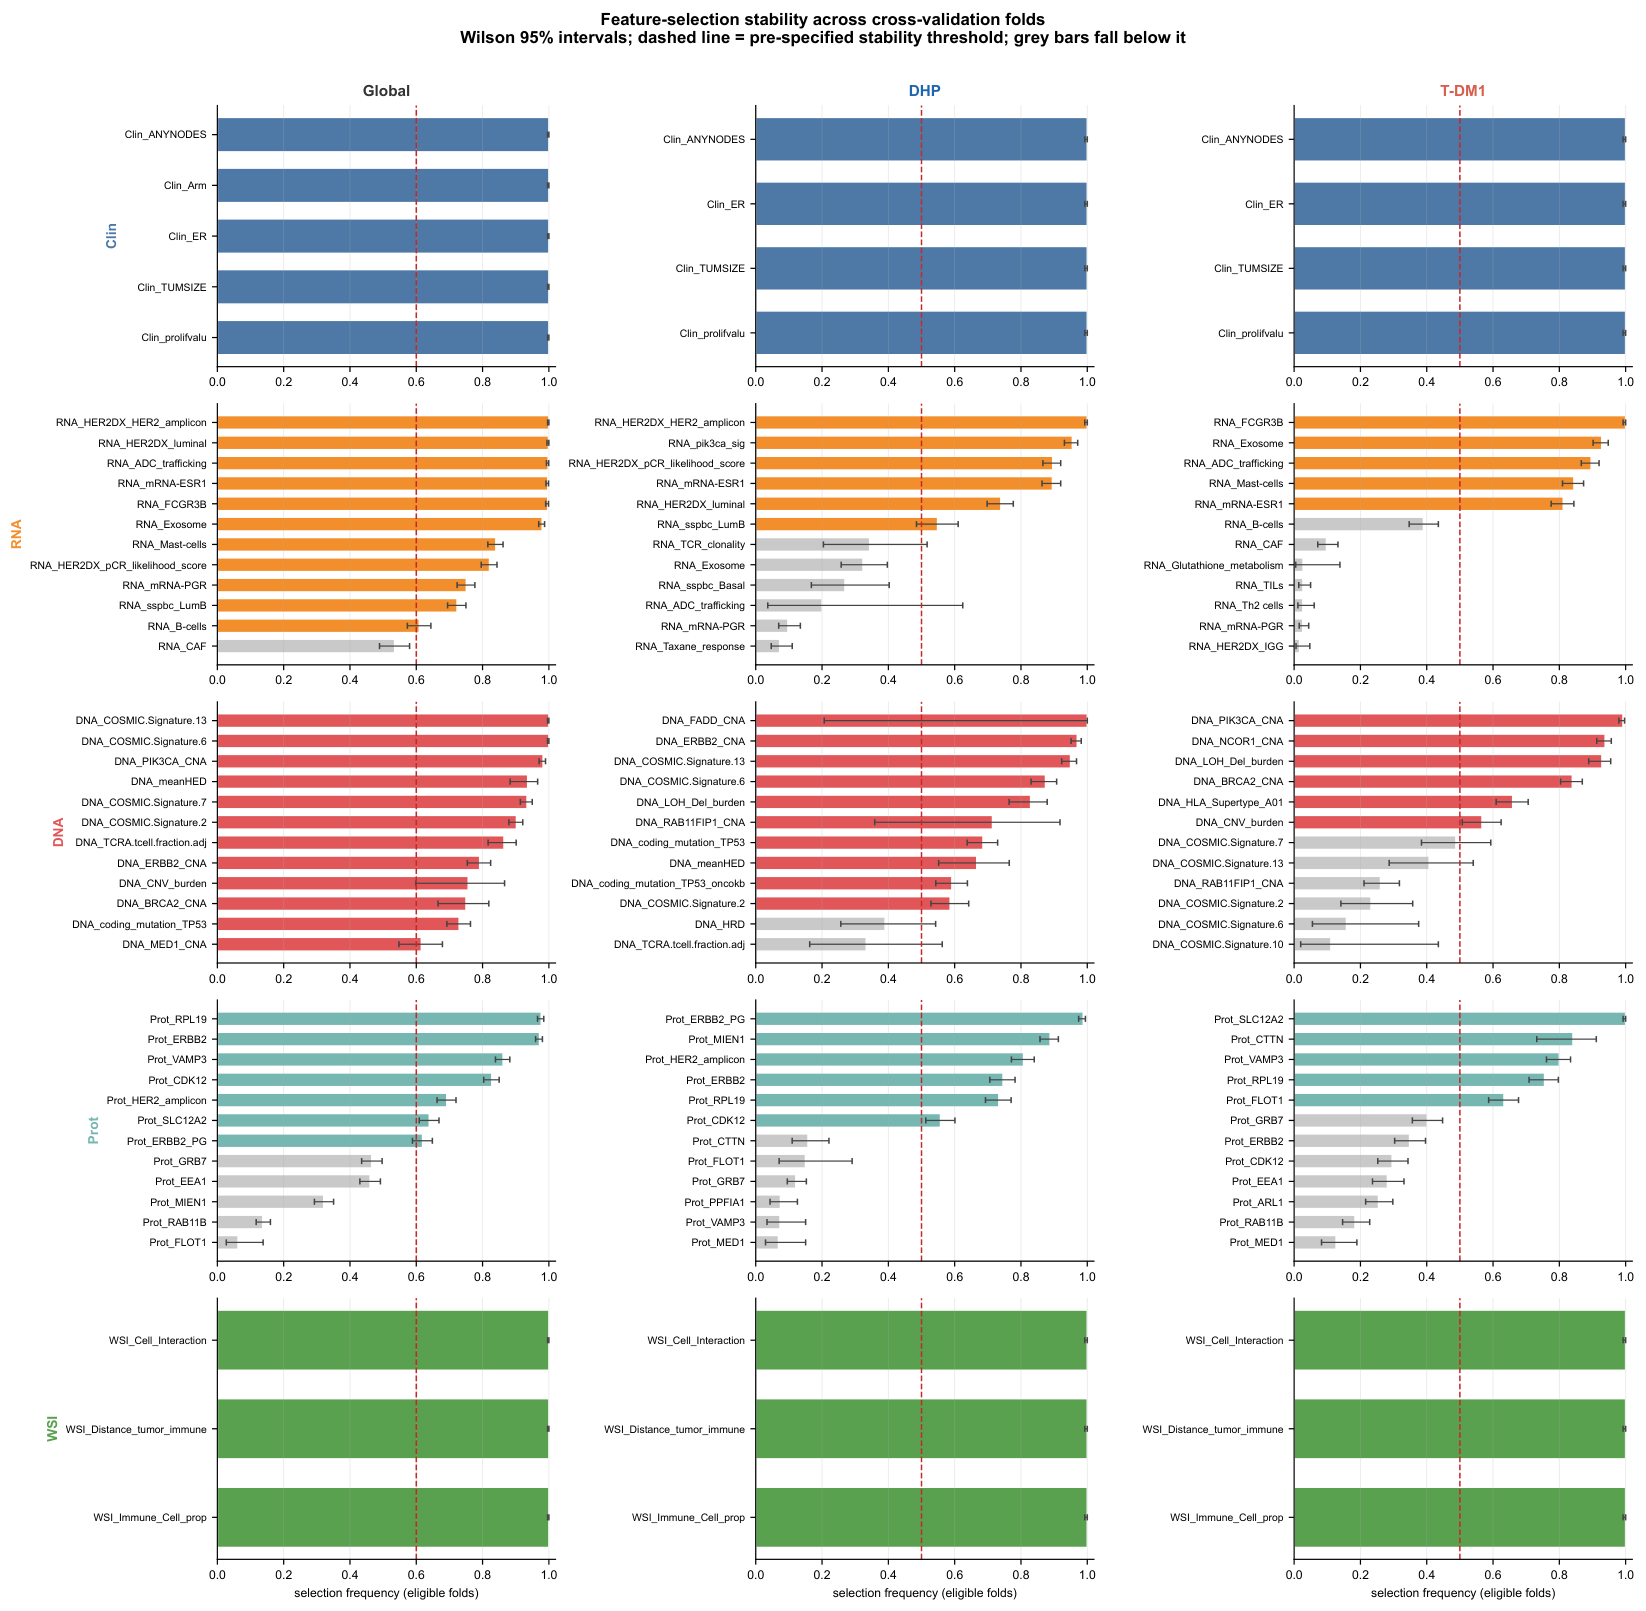

[deposited figure] report/figures/revision/revfig08_fusion_weights.pdf


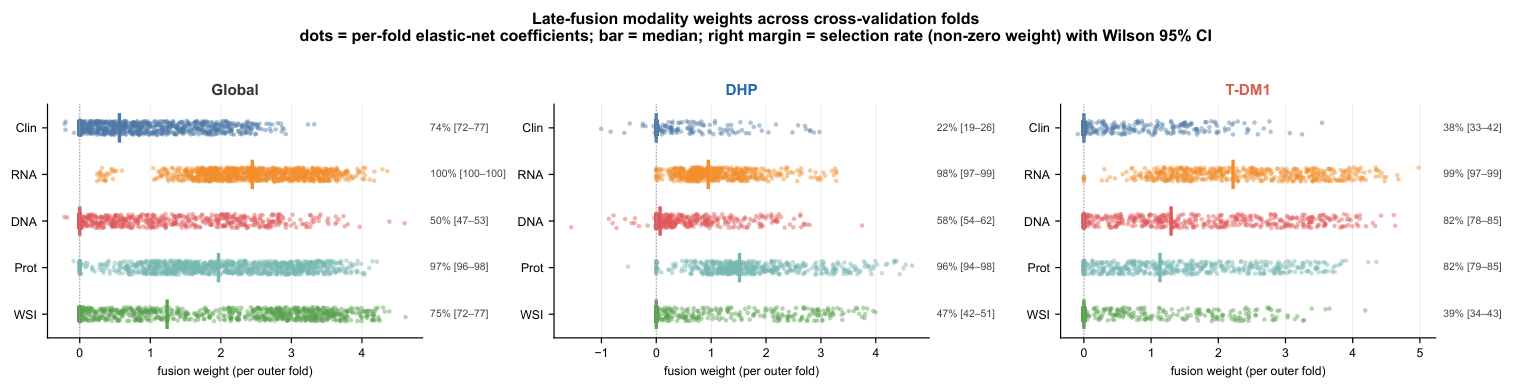

[deposited figure] report/figures/revision/revfig03_epv_per_fold.pdf


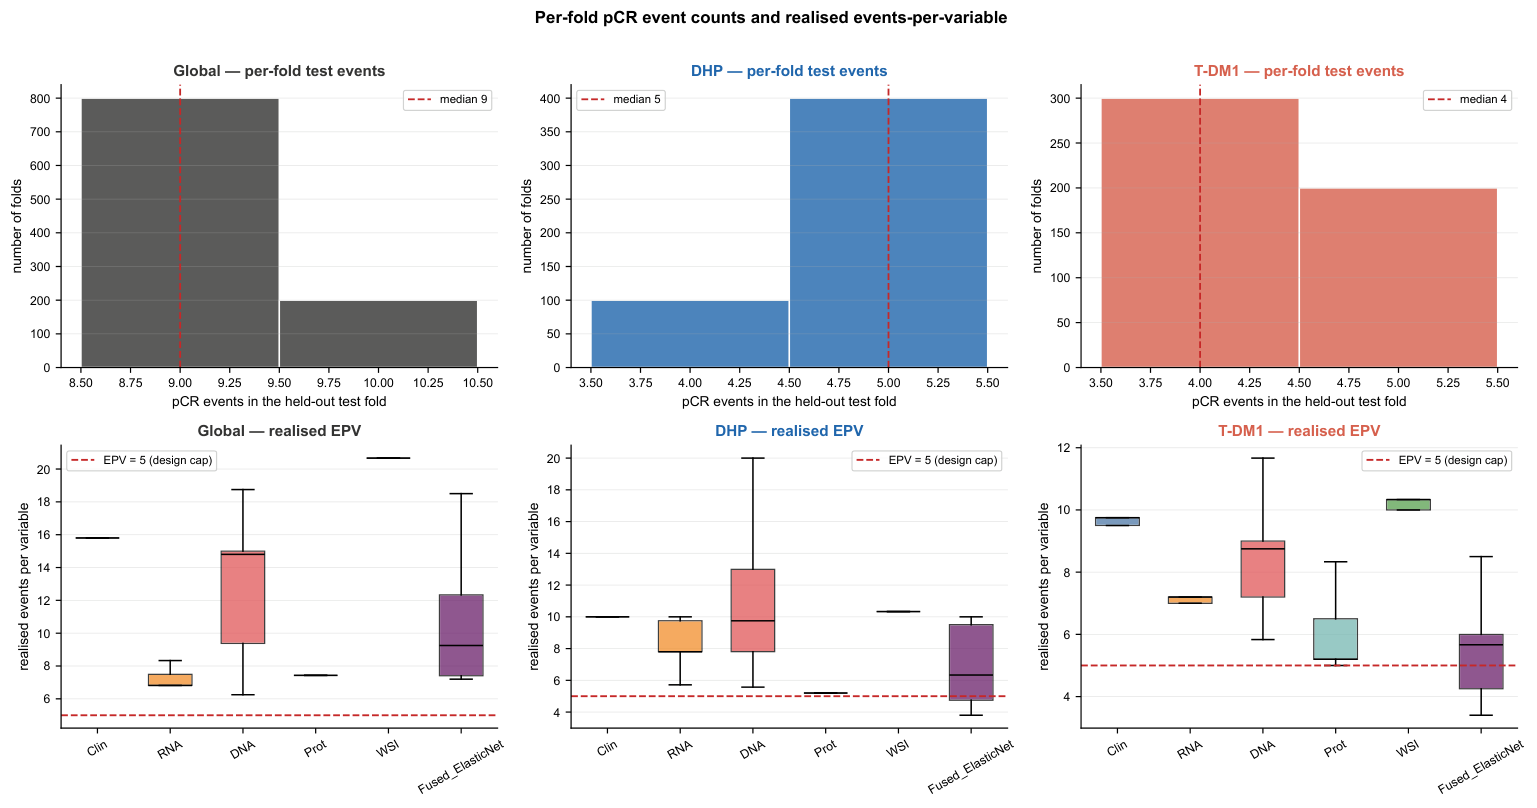

In [12]:
print("=" * 78); print("SECTION 9 — Stability, fusion weights, EPV"); print("=" * 78)
stab = read_sheet(PKG / "report/tables/revision/revision_stability.xlsx",
                  "Feature_selection_stability", "scenario")
print(f"Feature_selection_stability: {len(stab)} rows. Stable features per "
      f"scenario x modality (pre-specified thresholds Global 0.60 / arms 0.50):")
display(stab[stab["stable"] == True].groupby(["scenario", "modality"])
        .size().unstack().reindex(SCENARIOS)[UNIMODALS])
print("\nTop stable Global RNA features (all-fold selection frequency):")
display(stab[(stab.scenario == "Global") & (stab.modality == "RNA")]
        [["feature", "n_selected", "n_folds_total", "selection_freq",
          "selection_freq_eligible", "wilson_low", "stable"]].head(12))

mws = read_sheet(PKG / "report/tables/revision/revision_stability.xlsx",
                 "Modality_weight_stability", "scenario")
print("\nModality_weight_stability (discovery-phase fusion weights):")
display(mws[["scenario", "modality", "n_folds", "selection_rate", "mean_weight",
             "median_weight", "sign_consistency"]].round(3))

epv = read_sheet(PKG / "report/tables/revision/revision_epv_per_fold.xlsx",
                 "EPV_summary", "scenario")
print("\nEPV_summary (realised events-per-variable):")
display(epv[["scenario", "model", "n_folds", "median_n_events_test",
             "median_signature_size", "median_epv_realized", "min_epv_realized",
             "pct_folds_epv_below_5"]])

# ── Recomputation 1: selection frequency from the discovery PKL ──────────────
sf = RA.selection_frequency(DISC["Global"]["RNA"], threshold=0.60)
freq = float(sf.loc[sf.feature == "RNA_HER2DX_HER2_amplicon", "selection_freq"].iloc[0])
wb_freq = float(stab[(stab.scenario == "Global") & (stab.modality == "RNA")
                     & (stab.feature == "RNA_HER2DX_HER2_amplicon")]
                ["selection_freq"].iloc[0])
check("9", "RNA_HER2DX_HER2_amplicon selection frequency (Global RNA, 1000 folds) "
           "recomputed == workbook", close_to(freq, wb_freq),
      f"{freq:.3f} vs {wb_freq:.3f}")

# ── Recomputation 2: fusion selection rate from the consensus folds ──────────
w_rna = np.array([f["modality_weights"]["RNA"] for f in CONS["Global"]["folds"]])
rate = float(np.mean(np.abs(w_rna) > 1e-6))
fus = read_sheet(PKG / "report/tables/PREDIX_HER2_results.xlsx", "Fusion", "Scenario")
wb_rate = float(fus[(fus.Scenario == "Global") & (fus.Modality == "RNA")]
                ["Selection rate (|coef| > 1e-6)"].iloc[0])
check("9", "Global consensus fusion selection rate for RNA recomputed == Fusion "
           "sheet (1.000)", close_to(round(rate, 3), wb_rate, 1e-12) and rate == 1.0,
      f"{rate:.3f}")

# ── Recomputation 3: median test-fold events from the discovery PKL ──────────
ep = RA.epv_table(DISC["Global"][FUSED], "Global", FUSED)
med = float(ep["n_events_test"].median())
check("9", "median test-fold pCR events in Global == 9", med == 9.0, f"median={med:.0f}")

show_pdf(PKG / "report/figures/revision/revfig02_selection_stability.pdf")
show_pdf(PKG / "report/figures/revision/revfig08_fusion_weights.pdf")
show_pdf(PKG / "report/figures/revision/revfig03_epv_per_fold.pdf")

## 10. Consensus signatures

The scientific deliverable: one consensus signature per scenario × modality
(features above the pre-specified stability threshold; winner classifier = modal
classifier across folds), from the Signatures sheet of
`report/tables/PREDIX_HER2_results.xlsx`.

SECTION 10 — Consensus signatures
Signature sizes and winner classifiers:


,Scenario,Modality,K,winner_classifier
0,DHP,Clin,4,ElasticNet_LR
1,DHP,DNA,4,SVM_Linear
2,DHP,Prot,5,SVM_Linear
3,DHP,RNA,5,ElasticNet_LR
4,DHP,WSI,3,RandomForest
5,Global,Clin,5,SVM_Linear
6,Global,DNA,5,HistGradBoost
7,Global,Prot,7,SVM_Linear
8,Global,RNA,11,ExtraTrees
9,Global,WSI,3,ElasticNet_LR



Full signature listing:


,Scenario,Modality,Rank,Feature,Winner classifier,Signature size (K)
0,Global,Clin,1,Clin_ER,SVM_Linear,5
1,Global,Clin,2,Clin_ANYNODES,SVM_Linear,5
2,Global,Clin,3,Clin_TUMSIZE,SVM_Linear,5
3,Global,Clin,4,Clin_prolifvalu,SVM_Linear,5
4,Global,Clin,5,Clin_Arm,SVM_Linear,5
5,Global,RNA,1,RNA_HER2DX_HER2_amplicon,ExtraTrees,11
6,Global,RNA,2,RNA_mRNA-ESR1,ExtraTrees,11
7,Global,RNA,3,RNA_ADC_trafficking,ExtraTrees,11
8,Global,RNA,4,RNA_FCGR3B,ExtraTrees,11
9,Global,RNA,5,RNA_Exosome,ExtraTrees,11


[deposited figure] report/figures/fig02_consensus_signatures.pdf


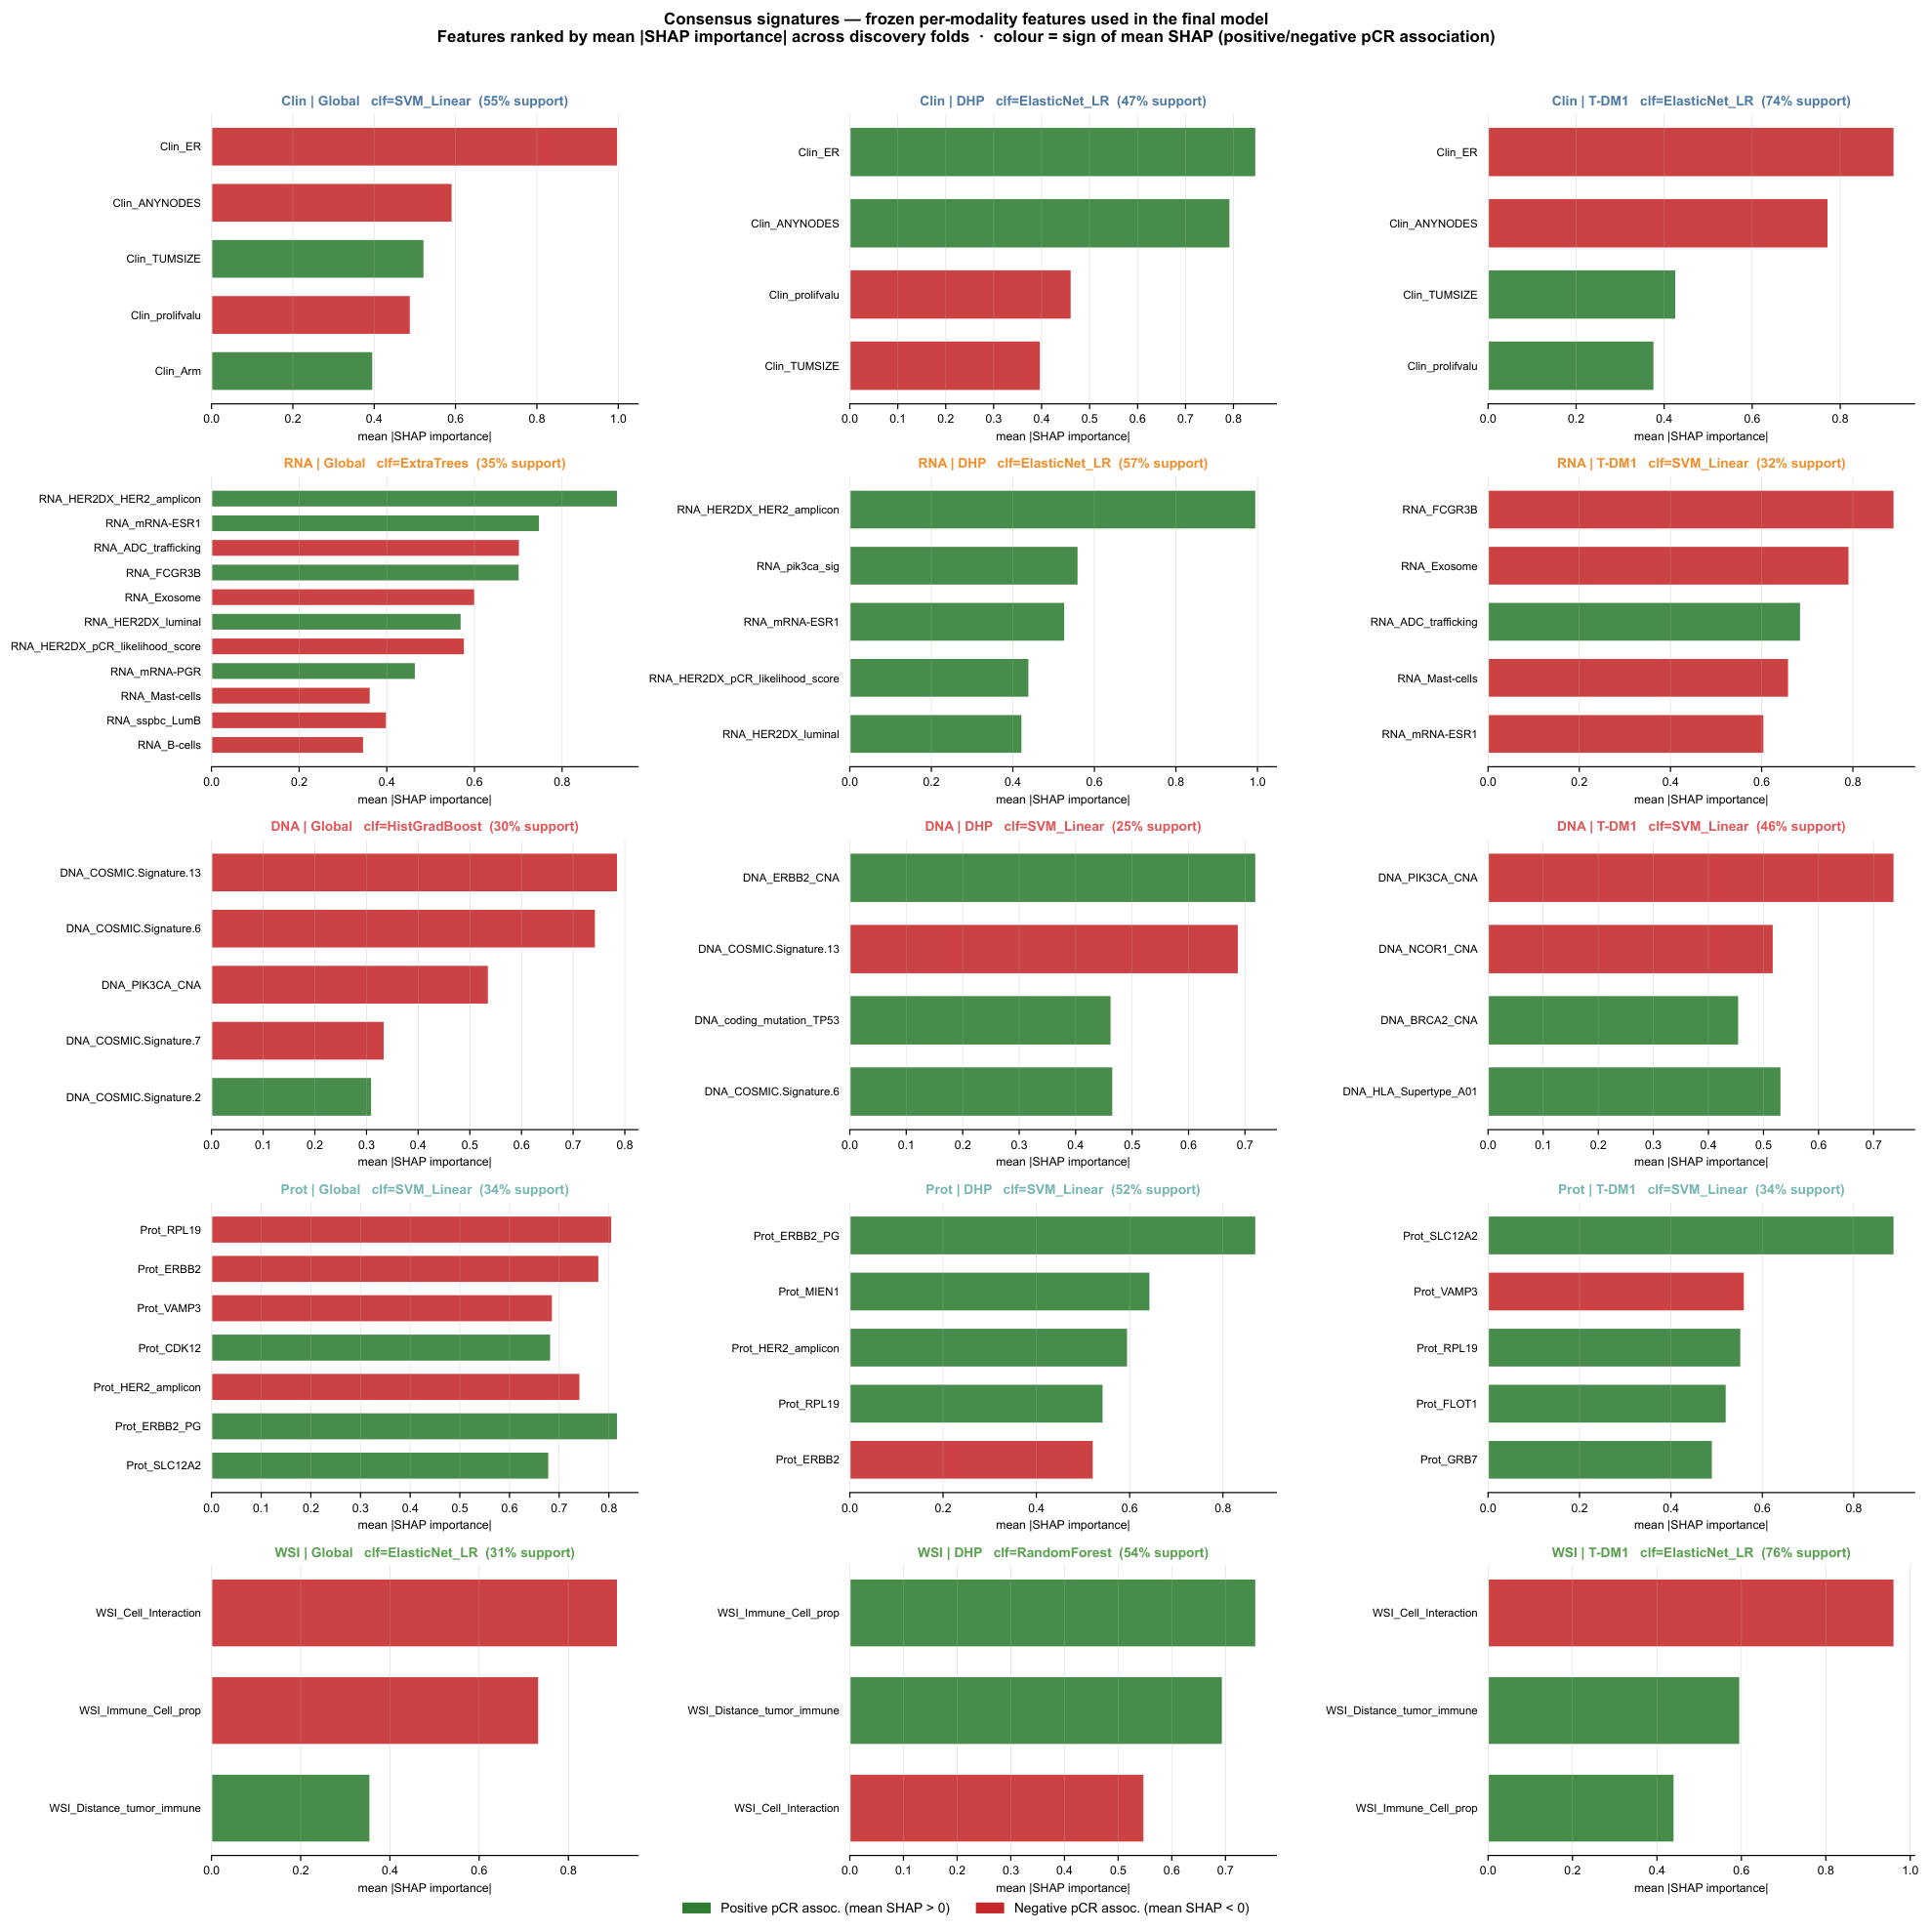

[deposited figure] report/figures/fig05_consensus_feature_shap_Global.pdf


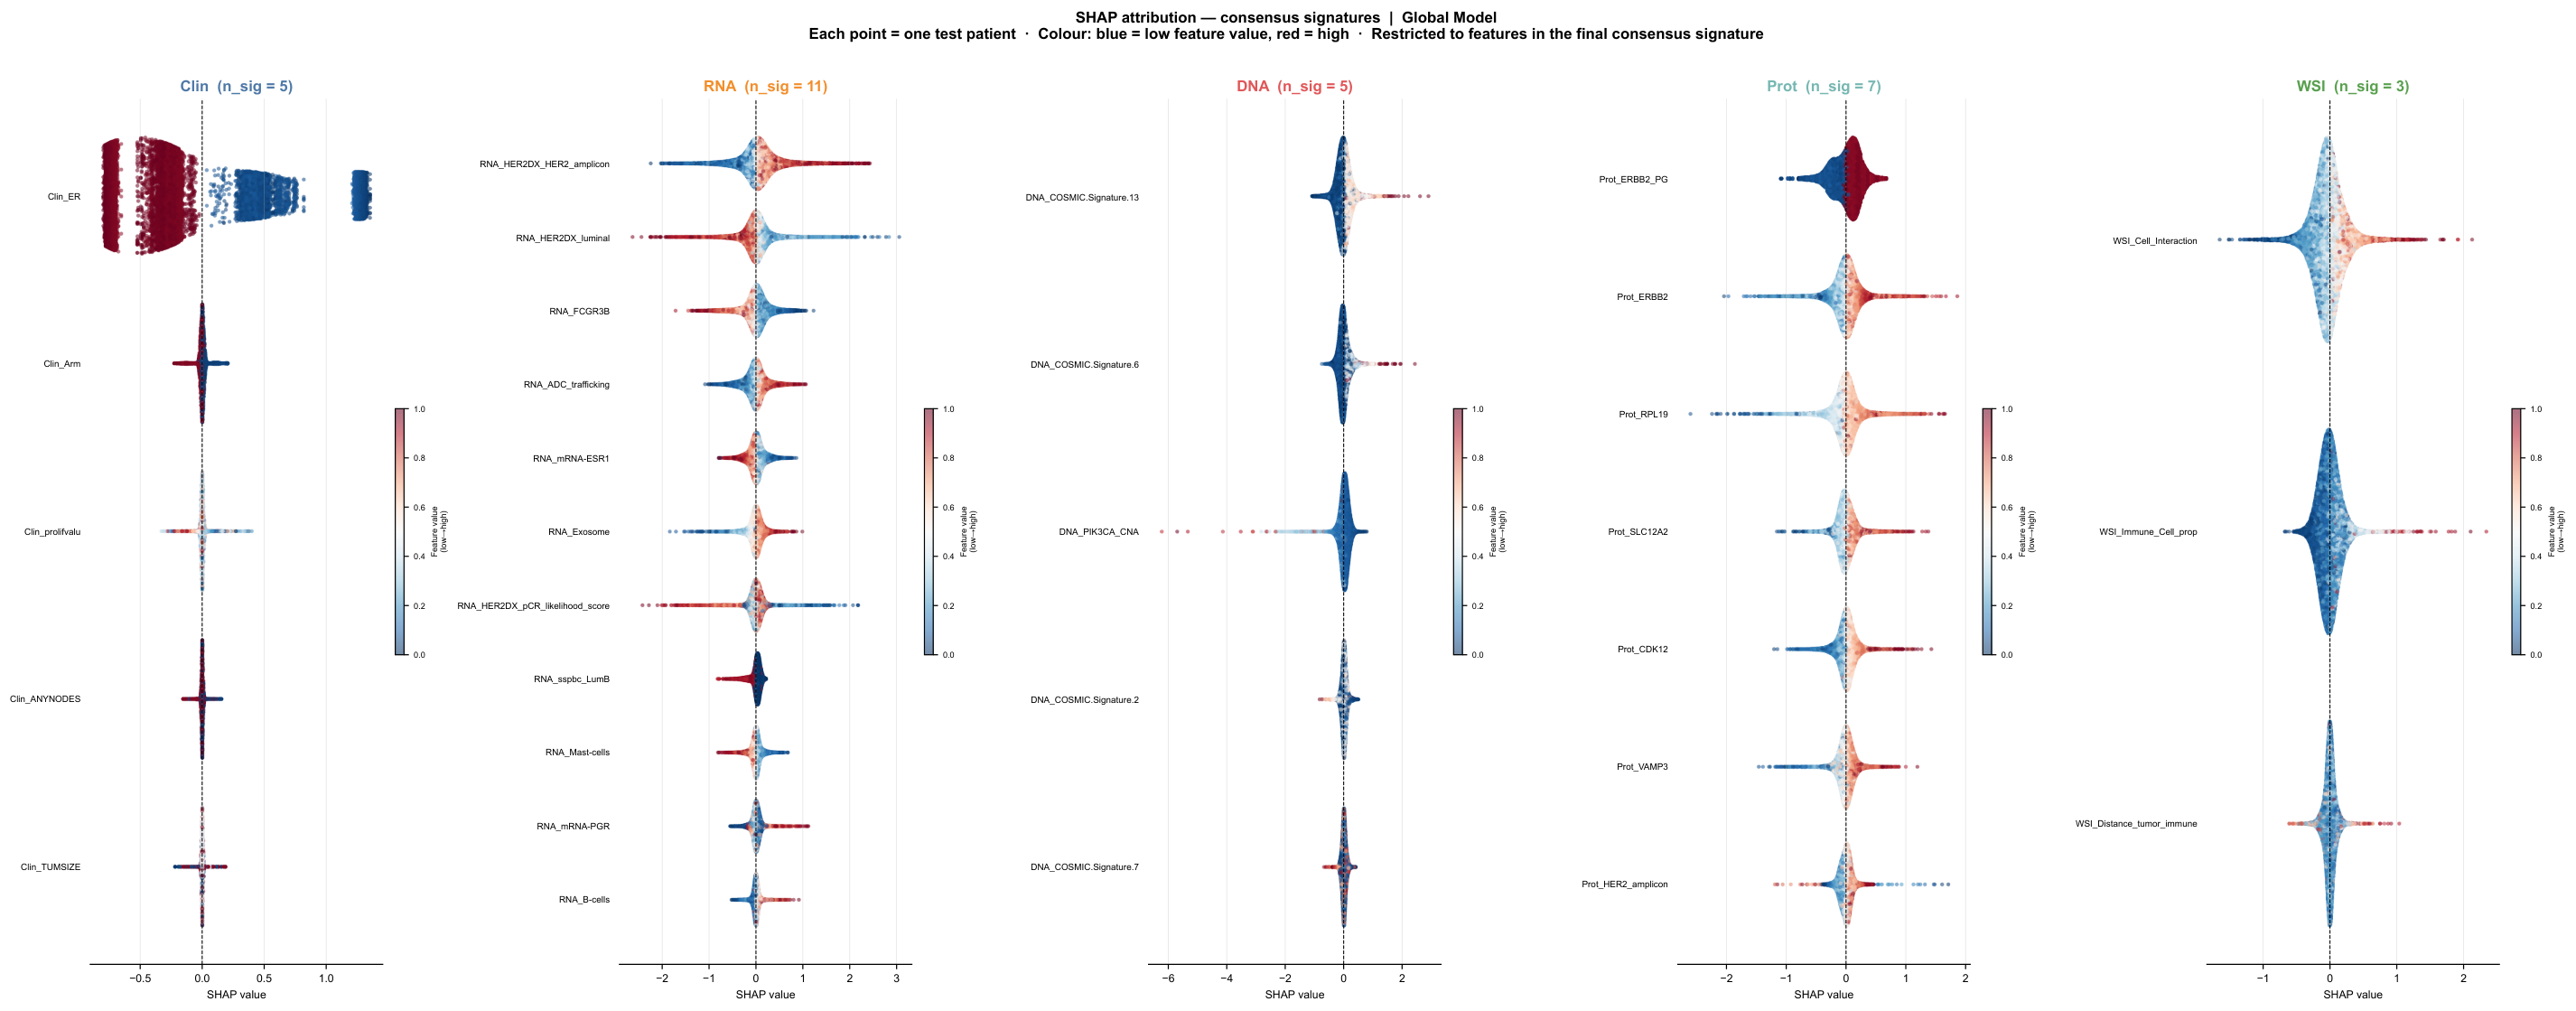

[deposited figure] report/figures/fig05_consensus_feature_shap_DHP.pdf


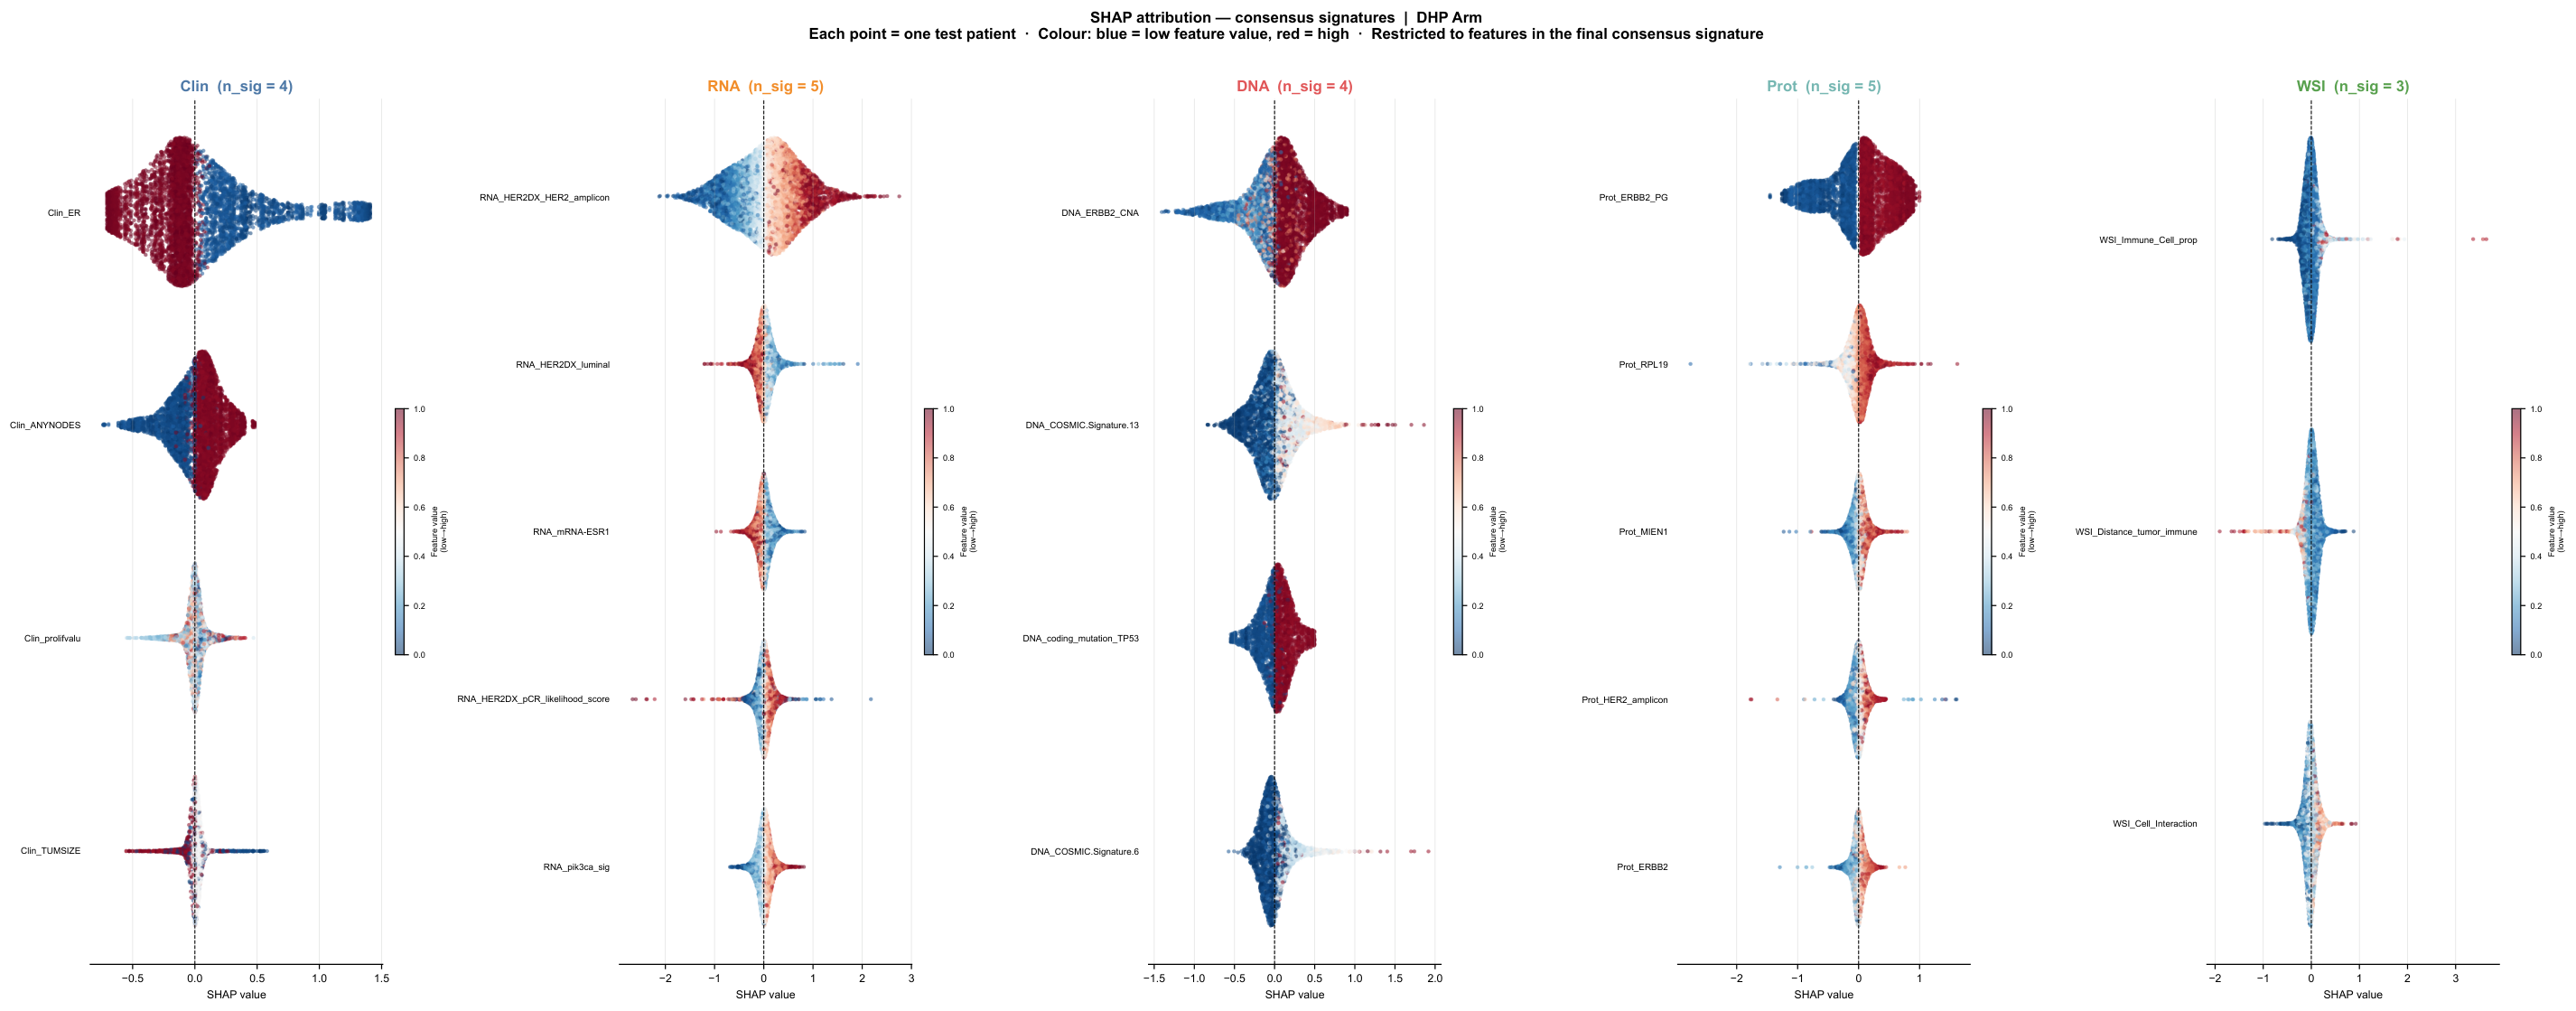

[deposited figure] report/figures/fig05_consensus_feature_shap_T_DM1.pdf

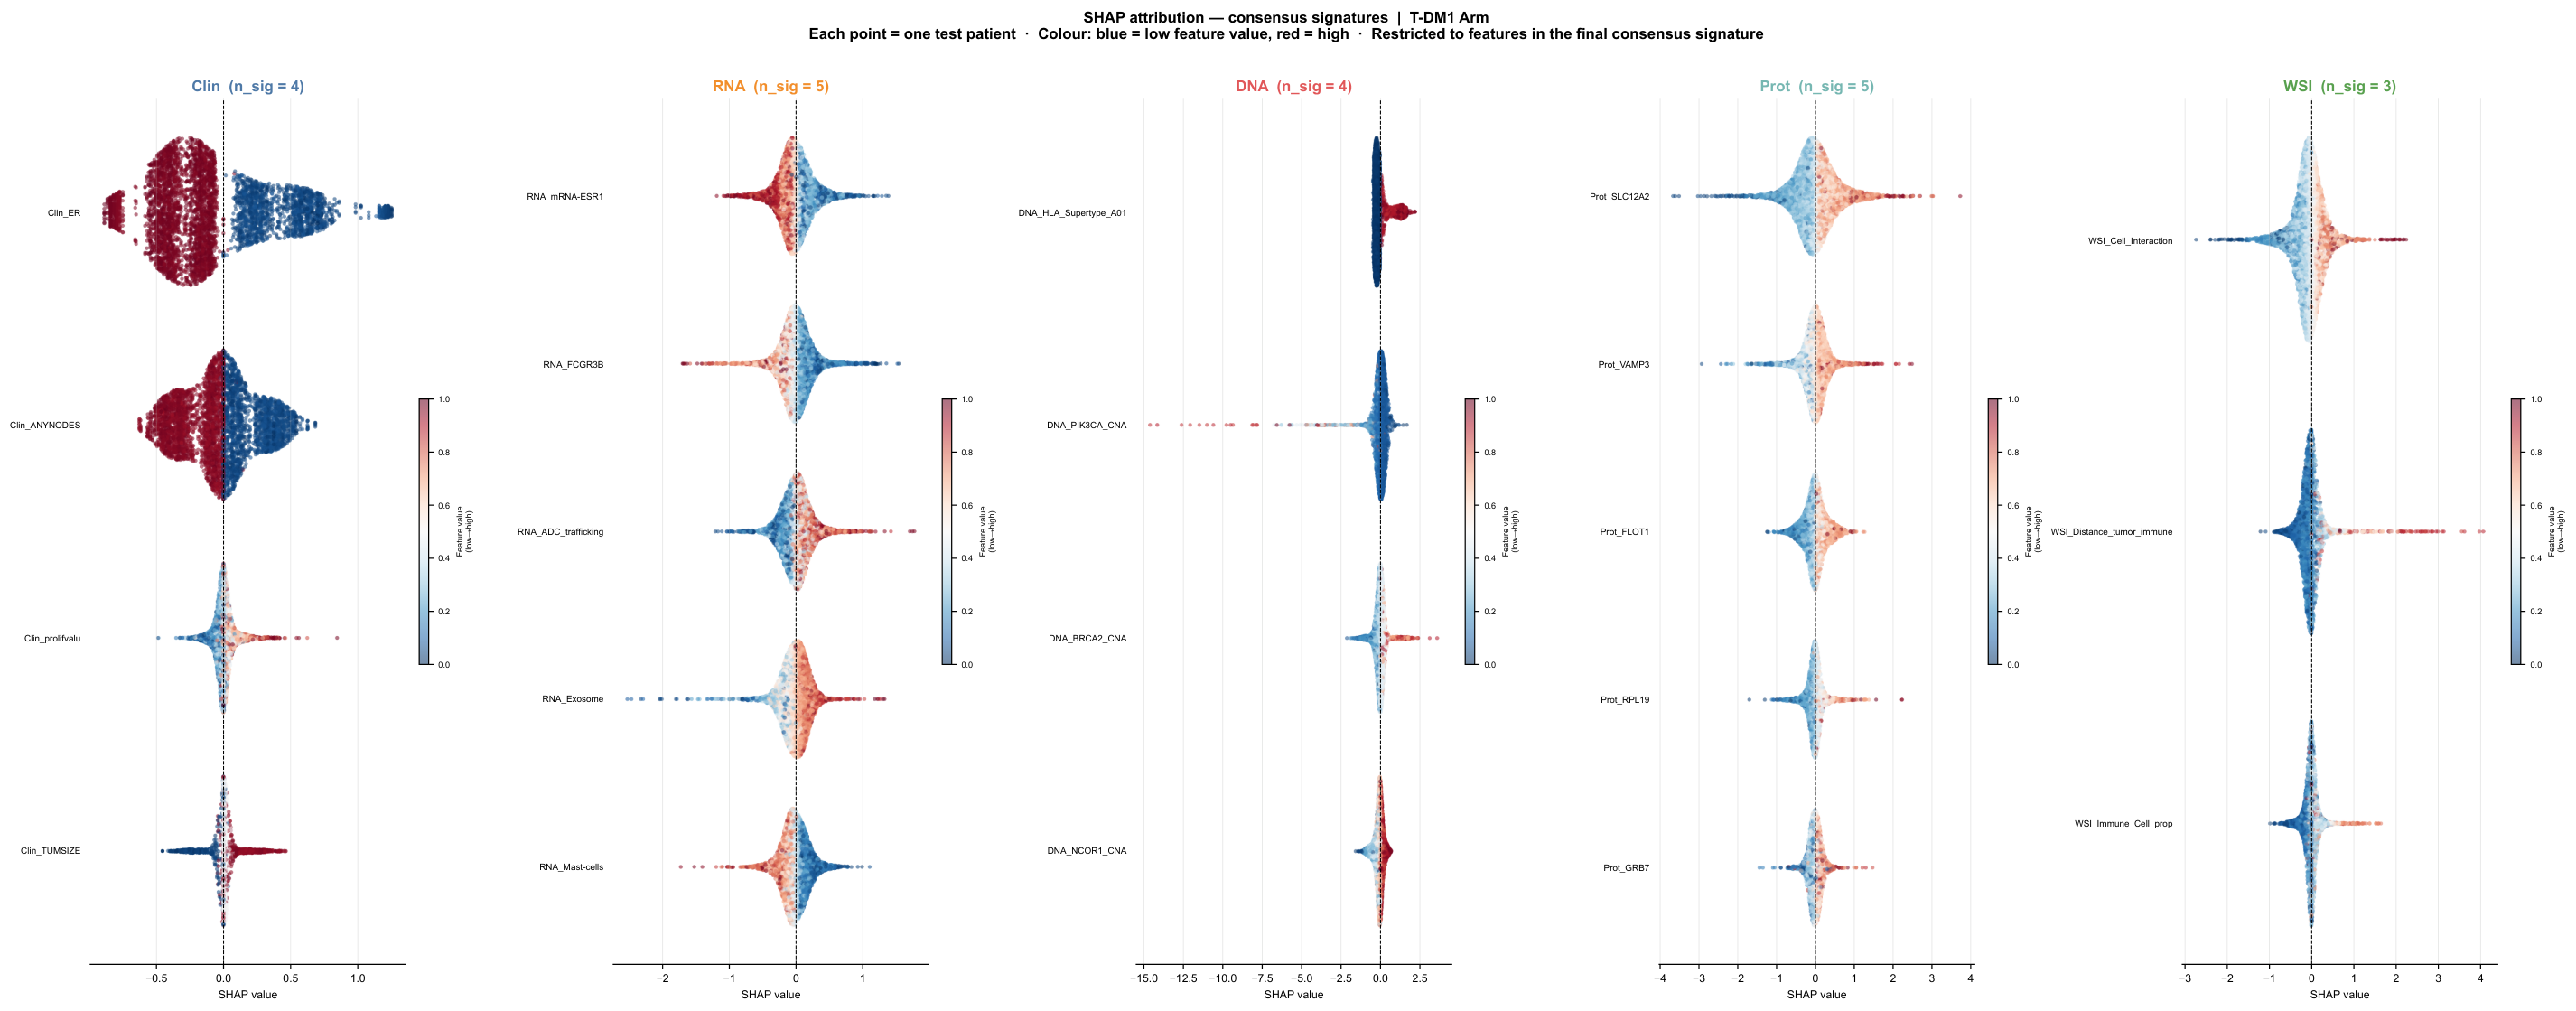

In [13]:
print("=" * 78); print("SECTION 10 — Consensus signatures"); print("=" * 78)
sig = read_sheet(PKG / "report/tables/PREDIX_HER2_results.xlsx", "Signatures", "Scenario")
print("Signature sizes and winner classifiers:")
display(sig.groupby(["Scenario", "Modality"]).agg(
    K=("Signature size (K)", "first"),
    winner_classifier=("Winner classifier", "first")).reset_index())
print("\nFull signature listing:")
display(sig[["Scenario", "Modality", "Rank", "Feature", "Winner classifier",
             "Signature size (K)"]])
show_pdf(PKG / "report/figures/fig02_consensus_signatures.pdf")
for tag in ("Global", "DHP", "T_DM1"):
    show_pdf(PKG / f"report/figures/fig05_consensus_feature_shap_{tag}.pdf")

## 11. Exploratory biomarker groups (S1/S2/S3) and the treatment interaction

**Exploratory, hypothesis-generating.** The S1/S2/S3 groups are re-derived here on
the full trial roster (n = 197 → 181 classifiable) with the published two-node
decision tree at the median split (q = 0.5), using the default driver
specification (`S_GROUP_SPEC_DEFAULT`; the driver columns are still to be
confirmed by the authors). The ER-adjusted treatment-by-group interaction LRT is
recomputed, together with the full cut-point sweep (q = 0.20–0.80). Because the
cut-points were optimised against this same outcome, the quotable p-value is the
**selective-inference permutation p** (the whole sweep repeated under 1,000
permutations of the randomised arm labels; seed 20240517), asserted below against
the deposited workbook.

In [14]:
print("=" * 78); print("SECTION 11 — S-groups: assignment, counts, interaction"); print("=" * 78)
DF_TRIAL = pd.read_csv(DATA_FILE, sep="\t")
# Identical loading to revision_analyses.main():
DF_TRIAL["patient_id"] = range(len(DF_TRIAL))
if not pd.api.types.is_numeric_dtype(DF_TRIAL["Clin_Arm"]):
    DF_TRIAL["Clin_Arm"] = DF_TRIAL["Clin_Arm"].map({"DHP": 0, "T-DM1": 1}).astype(float)
if not pd.api.types.is_numeric_dtype(DF_TRIAL["Clin_ER"]):
    DF_TRIAL["Clin_ER"] = DF_TRIAL["Clin_ER"].map(
        {"positive": 1, "negative": 0, "Positive": 1, "Negative": 0}).astype(float)

print("Driver specification (S_GROUP_SPEC_DEFAULT):", RA.S_GROUP_SPEC_DEFAULT)
labels, cut = RA.assign_s_groups(DF_TRIAL, q=0.5)
print("\nRealised thresholds at the median split:")
for role, c in cut.items():
    print(f"  {role:18s}: {c['column']} @ q={c['quantile']} -> {c['threshold']:.4f}")
counts = labels.value_counts()
print("\nGroup sizes:", dict(counts))
check("11", "group sizes S1/S2/S3/Unclassifiable = 50/87/44/16",
      tuple(int(counts.get(g, 0)) for g in ("S1", "S2", "S3", "Unclassifiable"))
      == (50, 87, 44, 16))

d = DF_TRIAL.copy(); d["group"] = labels
panel = d[d["group"] != "Unclassifiable"]
print("\npCR by group and arm (0 = DHP, 1 = T-DM1), Wilson 95% CI:")
display(RA.group_outcome_table(panel, "group", "Clin_Arm", "pCR").round(3))

inter = RA.interaction_lrt_adjusted(panel, "group", "Clin_Arm", "pCR",
                                    adjust_cols=("Clin_ER",))
print(f"\nER-adjusted interaction LRT: stat={inter['lrt_stat']:.6f}, df={inter['df']}, "
      f"nominal p={inter['p_value']:.6f}  (n={inter['n']}, events={inter['n_events']})")
WB_INT = read_sheet(PKG / "report/tables/revision/revision_biomarker_groups.xlsx",
                    "Interaction_test", "test").iloc[0]
check("11", "nominal interaction p reproduces the workbook (0.464)",
      close_to(inter["p_value"], WB_INT["nominal_p_value"]),
      f"{inter['p_value']:.9f}")
check("11", "n=181 classifiable, 82 events",
      (inter["n"], inter["n_events"]) == (181, 82))

print("\nCut-point sweep 0.20-0.80 (the published cut-point is the best of these):")
sweep, _ = RA.sweep_cutpoints(DF_TRIAL, "Clin_Arm", "pCR", adjust_cols=("Clin_ER",))
display(sweep.round(4))

SECTION 11 — S-groups: assignment, counts, interaction
Driver specification (S_GROUP_SPEC_DEFAULT): {'erbb2_scna': 'DNA_ERBB2_CNA', 'genome_instability': 'DNA_CNV_burden', 'adc_trafficking': 'RNA_ADC_trafficking', 'type2_immunity': 'RNA_Th2 cells'}

Realised thresholds at the median split:
  erbb2_scna        : DNA_ERBB2_CNA @ q=0.5 -> 2.7855
  genome_instability: DNA_CNV_burden @ q=0.5 -> 0.2151
  adc_trafficking   : RNA_ADC_trafficking @ q=0.5 -> -0.0656
  type2_immunity    : RNA_Th2 cells @ q=0.5 -> 0.0776

Group sizes: {'S2': np.int64(87), 'S1': np.int64(50), 'S3': np.int64(44), 'Unclassifiable': np.int64(16)}
  [PASS] group sizes S1/S2/S3/Unclassifiable = 50/87/44/16

pCR by group and arm (0 = DHP, 1 = T-DM1), Wilson 95% CI:


,group,arm,n,n_pCR,pCR_rate,pCR_ci_low,pCR_ci_high
0,S1,Overall,50,31,0.620,0.482,0.741
1,S1,0.0,27,19,0.704,0.515,0.841
2,S1,1.0,23,12,0.522,0.330,0.708
3,S2,Overall,87,30,0.345,0.253,0.449
4,S2,0.0,44,15,0.341,0.219,0.489
5,S2,1.0,43,15,0.349,0.224,0.498
6,S3,Overall,44,21,0.477,0.338,0.621
7,S3,0.0,23,10,0.435,0.256,0.632
8,S3,1.0,21,11,0.524,0.324,0.717



ER-adjusted interaction LRT: stat=1.536226, df=2, nominal p=0.463888  (n=181, events=82)
  [PASS] nominal interaction p reproduces the workbook (0.464)  (0.463887528)
  [PASS] n=181 classifiable, 82 events

Cut-point sweep 0.20-0.80 (the published cut-point is the best of these):


,cutpoint_quantile,n_classified,n_S1,n_S2,n_S3,interaction_LRT,interaction_df,interaction_p,n_events
0,0.20,181,130,27,24,3.1908,2,0.2028,82
1,0.25,181,121,33,27,4.4919,2,0.1058,82
2,0.30,181,109,44,28,5.4615,2,0.0652,82
3,0.35,181,93,53,35,2.9404,2,0.2299,82
4,0.40,181,80,63,38,3.7326,2,0.1547,82
5,0.45,181,62,79,40,3.7471,2,0.1536,82
6,0.50,181,50,87,44,1.5362,2,0.4639,82
7,0.55,181,39,97,45,6.6844,2,0.0354,82
8,0.60,181,33,105,43,6.6821,2,0.0354,82
9,0.65,181,29,114,38,5.4643,2,0.0651,82


Permutation test: the ENTIRE 13-cut-point sweep repeated under 1000 permutations of the arm labels (seed 20240517) ...


elapsed: 1.5 min
{'observed_min_p': 0.03535952296629445, 'best_cutpoint': 0.55, 'permutation_p': 0.25374625374625376, 'n_perm': 1000, 'n_cutpoints_searched': 13}
  [PASS] observed minimum sweep p matches the workbook
  [PASS] best cut-point in the sweep matches (q=0.55)
  [PASS] permutation-corrected p reproduces the workbook exactly (0.254)  (0.2537462537)

Manuscript context: the submission quoted P = 0.01 from the best cut-point of the sweep;
the selective-inference value that accounts for the search is p = 0.254.
[deposited figure] report/figures/revision/revfig04_biomarker_groups.pdf


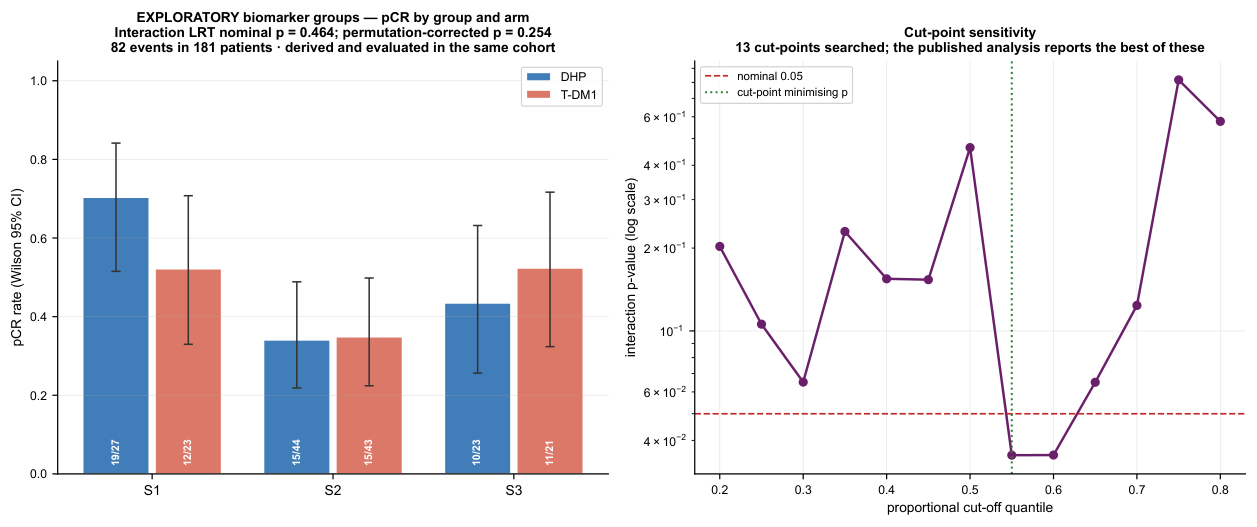

In [15]:
# ── The selective-inference permutation p (this IS the reproduction; ~minutes) ──
print("Permutation test: the ENTIRE 13-cut-point sweep repeated under 1000 "
      "permutations of the arm labels (seed 20240517) ...")
t0 = time.time()
perm = RA.cutpoint_permutation_p(DF_TRIAL, "Clin_Arm", "pCR",
                                 adjust_cols=("Clin_ER",), n_perm=1000)
dt = time.time() - t0
print(f"elapsed: {dt/60:.1f} min")
print({k: perm[k] for k in ("observed_min_p", "best_cutpoint",
                            "permutation_p", "n_perm", "n_cutpoints_searched")})
check("11", "observed minimum sweep p matches the workbook",
      close_to(perm["observed_min_p"], WB_INT["min_p_across_sweep"]))
check("11", "best cut-point in the sweep matches (q=0.55)",
      close_to(perm["best_cutpoint"], WB_INT["best_cutpoint_in_sweep"]))
check("11", "permutation-corrected p reproduces the workbook exactly (0.254)",
      close_to(perm["permutation_p"], WB_INT["permutation_corrected_p"], tol=1e-12),
      f"{perm['permutation_p']:.10f}")
print("\nManuscript context: the submission quoted P = 0.01 from the best cut-point "
      "of the sweep;\nthe selective-inference value that accounts for the search is "
      f"p = {perm['permutation_p']:.3f}.")
show_pdf(PKG / "report/figures/revision/revfig04_biomarker_groups.pdf")

## 12. External validation of the locked transcriptomic models

The locked pipeline-consensus RNA models (DHP model → I-SPY2 GSE194040; T-DM1
model → NCT02326974 GSE243375) were frozen on PREDIX and applied once to each
external cohort — nothing refitted, a SHA-256 provenance guard confirming both
steps saw the same input file. Two independent harmonisation schemes (`zscore`,
`rank`) are always reported.

Below: (i) the deposited workbook; (ii) the internal comparator recomputed from
the locked runs' consensus PKLs with the exact seed `external_validation.py`
uses (`BOOT_SEED = 20240517`); (iii) the **entire locked validation re-run** via
the script itself into `_regenerated/`, asserting the external AUROCs.

Reading: the DHP model **transfers** to I-SPY2 (external AUROC ≈ internal); the
T-DM1 model **fails to transfer** to NCT02326974 (external AUROC ≈ 0.55) — reported
as such in the revision.

In [16]:
print("=" * 78); print("SECTION 12 — External validation (deposited + internal comparator)"); print("=" * 78)
EV = read_sheet(PKG / "report/tables/revision/external_validation.xlsx",
                "External_validation", "cohort")
display(EV[["cohort", "matched_PREDIX_arm", "harmonisation", "model_source",
            "classifier", "hyperparameters", "n_model_features",
            "n_PREDIX_train", "events_PREDIX_train",
            "internal_AUROC_CI", "n_external", "events_external",
            "external_AUROC_CI", "external_AUPRC", "external_Brier",
            "calibration_slope", "p_vs_chance_one_sided"]].round(4))
print("\nFeature provenance (what transferred and why the rest did not):")
display(read_sheet(PKG / "report/tables/revision/external_validation.xlsx",
                   "Feature_provenance", "cohort"))

# ── Internal comparator recomputed from the locked runs' consensus PKLs ──────
# external_validation.py uses CE.bootstrap_repeat_metric_ci(..., seed=BOOT_SEED)
# (and BOOT_SEED+1 for AUPRC) on the consensus repeat matrix of the RNA model.
for cohort, resdir, exp in [("I-SPY2", "results_rna_ispy2", "dhp"),
                            ("NCT02326974", "results_rna_nct", "tdm1")]:
    with open(PKG / resdir / exp / f"{exp}_consensus_eval.pkl", "rb") as f:
        blob = pickle.load(f)
    rm = CE.consensus_repeat_matrix(blob, "RNA")
    res = CE.bootstrap_repeat_metric_ci(rm.P, rm.y, "AUROC",
                                        n_boot=N_BOOT, seed=BOOT_SEED)
    w = EV[EV.cohort == cohort].iloc[0]
    print(f"\n{cohort}: locked {exp.upper()} RNA model — internal CV "
          f"{rm.n_repeats} repeats x {rm.n_patients} patients ({rm.n_events} events)")
    print(f"  recomputed : {RA.format_ci(res)}")
    print(f"  deposited  : {w['internal_AUROC_CI']}")
    check("12", f"{cohort}: internal comparator AUROC reproduces the workbook",
          close_to(res["estimate"], w["internal_AUROC"])
          and RA.format_ci(res) == w["internal_AUROC_CI"],
          RA.format_ci(res))

SECTION 12 — External validation (deposited + internal comparator)


,cohort,matched_PREDIX_arm,harmonisation,model_source,classifier,hyperparameters,n_model_features,n_PREDIX_train,events_PREDIX_train,internal_AUROC_CI,n_external,events_external,external_AUROC_CI,external_AUPRC,external_Brier,calibration_slope,p_vs_chance_one_sided
0,I-SPY2,DHP,zscore,pipeline consensus (locked),ElasticNet_LR,{'C': 0.1},5,95,44,0.748 [0.653–0.839],44,26,0.774 [0.622–0.904],0.8241,0.1964,1.0734,0.0015
1,I-SPY2,DHP,rank,pipeline consensus (locked),ElasticNet_LR,{'C': 0.1},5,95,44,0.748 [0.653–0.839],44,26,0.793 [0.645–0.915],0.8372,0.1958,1.2055,0.0005
2,NCT02326974,T-DM1,zscore,pipeline consensus (locked),SVM_Linear,{'C': 0.1},5,90,40,0.787 [0.695–0.875],129,64,0.546 [0.444–0.641],0.5930,0.2835,0.2396,0.1674
3,NCT02326974,T-DM1,rank,pipeline consensus (locked),SVM_Linear,{'C': 0.1},5,90,40,0.787 [0.695–0.875],129,64,0.545 [0.442–0.641],0.5907,0.2764,0.2500,0.1714



Feature provenance (what transferred and why the rest did not):


,cohort,feature,status,reason
0,I-SPY2,RNA_HER2DX_HER2_amplicon,used,NaN
1,I-SPY2,RNA_HER2DX_pCR_likelihood_score,used,NaN
2,I-SPY2,RNA_HER2DX_luminal,used,NaN
3,I-SPY2,RNA_mRNA-ESR1,used,NaN
4,I-SPY2,RNA_pik3ca_sig,used,NaN
5,I-SPY2,RNA_TCR_clonality,excluded,not measured in external cohorts
6,I-SPY2,RNA_BCR_clonality,excluded,not measured in external cohorts
7,I-SPY2,RNA_ADC_trafficking,renamed,external file spells it 'RNA_ADC_traficking'
8,NCT02326974,RNA_Exosome,used,NaN
9,NCT02326974,RNA_ADC_trafficking,used,NaN



I-SPY2: locked DHP RNA model — internal CV 100 repeats x 95 patients (44 events)
  recomputed : 0.748 [0.653–0.839]
  deposited  : 0.748 [0.653–0.839]
  [PASS] I-SPY2: internal comparator AUROC reproduces the workbook  (0.748 [0.653–0.839])



NCT02326974: locked TDM1 RNA model — internal CV 100 repeats x 90 patients (40 events)
  recomputed : 0.787 [0.695–0.875]
  deposited  : 0.787 [0.695–0.875]
  [PASS] NCT02326974: internal comparator AUROC reproduces the workbook  (0.787 [0.695–0.875])


Re-running the locked external validation via code/external_validation.py
(the provenance guard re-checks the SHA-256 of the input file against the
locked runs' run_provenance.json) ...


exit code 0 after 0.9 min; last 12 lines:

  -> revfig06_external_validation.pdf

EXTERNAL VALIDATION SUMMARY  (AUROC [95% CI])
  internal (locked rows) = mean over CV repeats of the pooled out-of-fold AUROC;
                           95% patient-level cluster-bootstrap CI
  I-SPY2         zscore  internal 0.748 [0.653â€“0.839]  ->  external 0.774 [0.622â€“0.904]   (n=44, 26 events, 5 features)
  I-SPY2         rank    internal 0.748 [0.653â€“0.839]  ->  external 0.793 [0.645â€“0.915]   (n=44, 26 events, 5 features)
  NCT02326974    zscore  internal 0.787 [0.695â€“0.875]  ->  external 0.546 [0.444â€“0.641]   (n=129, 64 events, 5 features)
  NCT02326974    rank    internal 0.787 [0.695â€“0.875]  ->  external 0.545 [0.442â€“0.641]   (n=129, 64 events, 5 features)
  [PASS] locked external validation re-ran cleanly (SHA provenance guard passed)
  I-SPY2       zscore  regenerated 0.7735042735  vs deposited 0.7735042735
  I-SPY2       rank    regenerated 0.7927350427  vs deposited 0.7927350

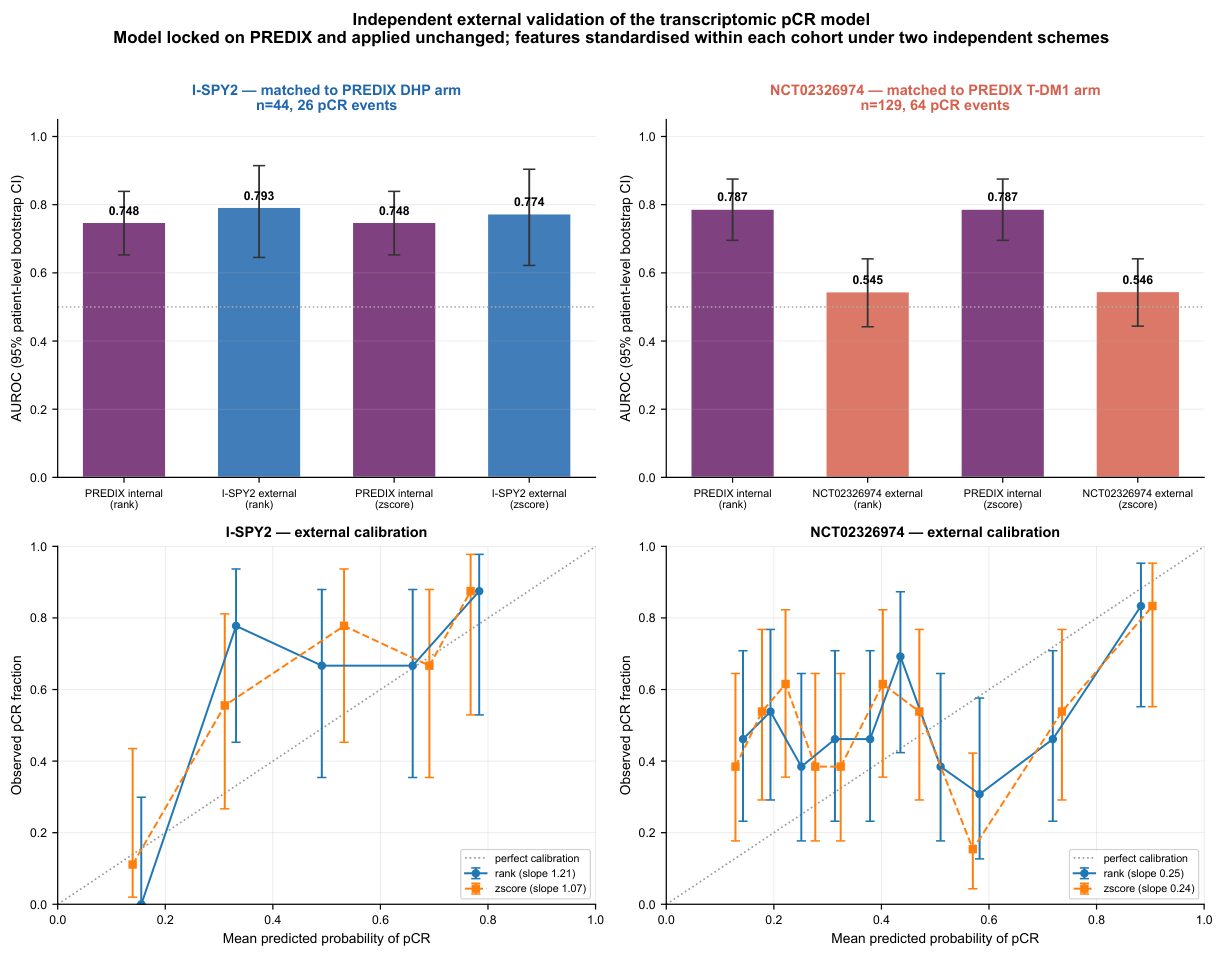

In [17]:
# ── Re-run the locked external validation itself (subprocess) ────────────────
print("Re-running the locked external validation via code/external_validation.py")
print("(the provenance guard re-checks the SHA-256 of the input file against the")
print("locked runs' run_provenance.json) ...")
cmd = [sys.executable, "code/external_validation.py",
       "--predix", "data/clin_multiomics_curated_metrics_PREDIX_HER2_new.txt",
       "--ispy2", "data/RNA_curated_metrics_ISPY2.txt",
       "--nct", "data/RNA_curated_metrics_NCT02326974.txt",
       "--locked_ispy2", "results_rna_ispy2", "--locked_nct", "results_rna_nct",
       "--out_dir", "_regenerated", "--n_boot", "2000"]
t0 = time.time()
r = subprocess.run(cmd, capture_output=True, text=True, cwd=str(PKG))
T_EXTVAL = time.time() - t0
print(f"exit code {r.returncode} after {T_EXTVAL/60:.1f} min; last 12 lines:\n")
print("\n".join(r.stdout.strip().splitlines()[-12:]))
if r.returncode != 0:
    print("\nSTDERR (tail):\n", r.stderr[-4000:])
check("12", "locked external validation re-ran cleanly (SHA provenance guard passed)",
      r.returncode == 0)

regen = read_sheet(PKG / "_regenerated/tables/revision/external_validation.xlsx",
                   "External_validation", "cohort").set_index(["cohort", "harmonisation"])
dep = EV.set_index(["cohort", "harmonisation"])
maxd, n_bad = 0.0, 0
for key in [("I-SPY2", "zscore"), ("I-SPY2", "rank"),
            ("NCT02326974", "zscore"), ("NCT02326974", "rank")]:
    a = float(regen.loc[key, "external_AUROC"])
    b = float(dep.loc[key, "external_AUROC"])
    maxd = max(maxd, abs(a - b))
    print(f"  {key[0]:<12} {key[1]:<7} regenerated {a:.10f}  vs deposited {b:.10f}")
    if abs(a - b) > 1e-6:
        n_bad += 1
check("12", "external AUROCs reproduce the deposited workbook "
            f"(0.7735 / 0.7927 / 0.5457 / 0.5450; max |diff| = {maxd:.2e}, tol 1e-6)",
      n_bad == 0)
show_pdf(PKG / "report/figures/revision/revfig06_external_validation.pdf")

## 13. Full regeneration of the deposited report (Level A, complete)

The two post-processing scripts are now run end-to-end on the deposited PKLs into
`_regenerated/`, exactly as in production
(`generate_report.py --results_dir results`; `revision_analyses.py ...
--n_boot 2000 --n_perm 1000`). Every regenerated workbook is then compared with
its deposited counterpart **sheet by sheet, cell by cell, in its natural row
order** (strings exact; numbers to 1e-9).

Exactly one difference is tolerated, and it is printed rather than silently
skipped: the `locked_from` column of `external_validation.xlsx` records the
`--locked_*` path exactly as typed on the command line, and the production run
was launched with a different relative path prefix. It is a recorded CLI
string, not a result. Every other cell — every AUROC, interval, p-value,
selection frequency, weight and count — must match to 1e-9.

*A note on determinism.* An earlier run of this notebook found 46 further
differing cells in the `Feature_selection_stability` sheet, which turned out to
be a pure row permutation: `selection_frequency()` accumulated rows in the
iteration order of a `set` of feature names, which varies with Python's
per-process string-hash randomisation, and the sort over selection frequency
was not stable, so features tied at the same frequency were emitted in a
different order on every run. No value was affected. The function now sorts by
`(selection_freq_eligible, selection_freq, feature)` with a stable sort, the
test suite checks that order, and the sheet is compared here in its natural
order with no special handling.

Figure PDFs are regenerated too; being binary files with embedded creation
timestamps they are compared by presence, not bytes.

In [18]:
print("=" * 78); print("SECTION 13a — generate_report.py on the deposited PKLs"); print("=" * 78)
t0 = time.time()
r = subprocess.run([sys.executable, "code/generate_report.py",
                    "--results_dir", "results", "--out_dir", "_regenerated"],
                   capture_output=True, text=True, cwd=str(PKG))
T_GENREP = time.time() - t0
print(f"exit code {r.returncode} after {T_GENREP/60:.1f} min; last 8 lines:\n")
print("\n".join(r.stdout.strip().splitlines()[-8:]))
if r.returncode != 0:
    print("\nSTDERR (tail):\n", r.stderr[-4000:])
check("13", "generate_report.py completed", r.returncode == 0)

SECTION 13a — generate_report.py on the deposited PKLs


exit code 0 after 4.0 min; last 8 lines:

  â†’ PREDIX_HER2_results.xlsx
  â†’ PREDIX_HER2_performance_CI.xlsx
  â†’ PREDIX_HER2_feature_pruning_report.xlsx
  â†’ pooled_operating_points.xlsx

Done.  Main-text figures  (8) â†’ _regenerated\figures
       Supplementary figs (16) â†’ _regenerated\figures\supplementary
       Tables            â†’ _regenerated\tables
  [PASS] generate_report.py completed


True

In [19]:
print("=" * 78); print("SECTION 13b — revision_analyses.py on the deposited PKLs"); print("=" * 78)
t0 = time.time()
r = subprocess.run([sys.executable, "code/revision_analyses.py",
                    "--results_dir", "results", "--out_dir", "_regenerated",
                    "--data_path", "data/clin_multiomics_curated_metrics_PREDIX_HER2_new.txt",
                    "--n_boot", "2000", "--n_perm", "1000"],
                   capture_output=True, text=True, cwd=str(PKG))
T_REVAN = time.time() - t0
print(f"exit code {r.returncode} after {T_REVAN/60:.1f} min; last 10 lines:\n")
print("\n".join(r.stdout.strip().splitlines()[-10:]))
if r.returncode != 0:
    print("\nSTDERR (tail):\n", r.stderr[-4000:])
check("13", "revision_analyses.py completed", r.returncode == 0)

SECTION 13b — revision_analyses.py on the deposited PKLs


exit code 0 after 5.2 min; last 10 lines:

  -> revfig04_biomarker_groups.pdf

[extra] Exploratory survival analysis ...
  [SURVIVAL] Columns 'EFS_months' / 'EFS_event' not found in the dataset â€” skipping. Pass --survival_time_col and --survival_event_col to enable this section.

REVISION ANALYSES COMPLETE
  Tables  -> _regenerated\tables\revision
  Figures -> _regenerated\figures\revision
  [PASS] revision_analyses.py completed


True

In [20]:
# ── Cell-by-cell comparison of every regenerated workbook ───────────────────
from openpyxl.utils import get_column_letter

def sheet_grid(ws):
    return [[c.value for c in row] for row in ws.iter_rows()]

def cells_equal(va, vb):
    if va is None or vb is None:
        return va is None and vb is None
    if isinstance(va, bool) or isinstance(vb, bool):
        return va == vb
    if isinstance(va, (int, float)) and isinstance(vb, (int, float)):
        return close_to(va, vb)
    return va == vb

def canonicalise(grid, first_header, n_key):
    # Sort the body rows (below the header row that starts with `first_header`)
    # by their first n_key columns. Returns (grid, n_moved).
    hdr_i = next((i for i, r in enumerate(grid) if r and r[0] == first_header), None)
    if hdr_i is None:
        return grid, 0
    head, body = grid[:hdr_i + 1], grid[hdr_i + 1:]
    key = lambda r: tuple(str(v) for v in r[:n_key])
    body_sorted = sorted(body, key=key)
    n_moved = sum(1 for a, b in zip(body, body_sorted) if key(a) != key(b))
    return head + body_sorted, n_moved

def compare_workbooks(dep_path, reg_path, skip_cols=None, key_sheets=None):
    wa = openpyxl.load_workbook(dep_path, data_only=True)
    wb_ = openpyxl.load_workbook(reg_path, data_only=True)
    out = dict(n_sheets=len(wa.sheetnames), n_cells=0, n_mismatch=0,
               n_skipped=0, n_reordered=0, first="", skipped_examples=[])
    if wa.sheetnames != wb_.sheetnames:
        out["n_mismatch"] = -1
        out["first"] = f"sheet names differ: {wa.sheetnames} vs {wb_.sheetnames}"
        return out
    for sn in wa.sheetnames:
        ga, gb = sheet_grid(wa[sn]), sheet_grid(wb_[sn])
        if key_sheets and sn in key_sheets:
            first_header, n_key = key_sheets[sn]
            ga, m_a = canonicalise(ga, first_header, n_key)
            gb, m_b = canonicalise(gb, first_header, n_key)
            out["n_reordered"] += max(m_a, m_b)
        skip_idx, hdr_row = set(), None
        names = (skip_cols or {}).get(sn, [])
        if names:
            for ri, row in enumerate(ga[:40]):
                hits = [ci for ci, v in enumerate(row) if v in names]
                if hits:
                    skip_idx, hdr_row = set(hits), ri
                    break
        n_rows = max(len(ga), len(gb))
        for ri in range(n_rows):
            ra = ga[ri] if ri < len(ga) else []
            rb = gb[ri] if ri < len(gb) else []
            n_c = max(len(ra), len(rb))
            for ci in range(n_c):
                va = ra[ci] if ci < len(ra) else None
                vb = rb[ci] if ci < len(rb) else None
                if ci in skip_idx and hdr_row is not None and ri > hdr_row:
                    if not cells_equal(va, vb):
                        out["n_skipped"] += 1
                        out["skipped_examples"].append(
                            f"{sn}!{get_column_letter(ci+1)}{ri+1}: {va!r} vs {vb!r}")
                    continue
                out["n_cells"] += 1
                if not cells_equal(va, vb):
                    out["n_mismatch"] += 1
                    if not out["first"]:
                        out["first"] = (f"{sn}!{get_column_letter(ci+1)}{ri+1}: "
                                        f"deposited {va!r} vs regenerated {vb!r}")
    return out

dep_root = PKG / "report" / "tables"
reg_root = PKG / "_regenerated" / "tables"
dep_files = sorted(p.relative_to(dep_root).as_posix() for p in dep_root.rglob("*.xlsx"))
reg_files = sorted(p.relative_to(reg_root).as_posix() for p in reg_root.rglob("*.xlsx"))
print(f"deposited workbooks: {len(dep_files)}; regenerated workbooks: {len(reg_files)}")
extras = sorted(set(reg_files) - set(dep_files))
if extras:
    print("regenerated-only files (not deposited):", extras)

# The locked_from column records the --locked_* CLI path exactly as typed; the
# production run used the prefix 'ubuntu_results\'. A path string, not a number.
SKIP = {"revision/external_validation.xlsx": {"External_validation": ["locked_from"]}}
# No sheet needs canonicalising. Feature_selection_stability used to differ by
# a row permutation between processes (set-iteration order + a non-stable sort);
# selection_frequency() now sorts by (selection_freq_eligible, selection_freq,
# feature) with a stable sort, so every sheet is compared in its natural row
# order. Leaving this empty keeps the check strict: a future regression in row
# ordering would fail here instead of being canonicalised away.
KEYED = {}

t0 = time.time()
summary, total_bad, total_skipped, total_reordered = [], 0, 0, 0
for rel in dep_files:
    reg = reg_root / rel
    if not reg.exists():
        summary.append(dict(file=rel, sheets=0, cells_compared=0, mismatches=-1,
                            skipped_path_cells=0, reordered_rows=0,
                            first_mismatch="MISSING in _regenerated"))
        total_bad += 1
        continue
    res = compare_workbooks(dep_root / rel, reg, skip_cols=SKIP.get(rel),
                            key_sheets=KEYED.get(rel))
    summary.append(dict(file=rel, sheets=res["n_sheets"], cells_compared=res["n_cells"],
                        mismatches=res["n_mismatch"], skipped_path_cells=res["n_skipped"],
                        reordered_rows=res["n_reordered"], first_mismatch=res["first"]))
    total_bad += max(res["n_mismatch"], 0) + (1 if res["n_mismatch"] < 0 else 0)
    total_skipped += res["n_skipped"]
    total_reordered += res["n_reordered"]
    for ex in res["skipped_examples"]:
        print(f"  [explained path-recording difference] {rel} {ex}")
    if res["n_reordered"]:
        print(f"  [explained row-order difference] {rel} Feature_selection_stability: "
              f"{res['n_reordered']} rows repositioned inside ties of "
              f"selection_freq_eligible (hash-seed-dependent set order); all row "
              f"CONTENT compared keyed by (scenario, modality, feature) at 1e-9.")
SUMMARY = pd.DataFrame(summary)
print(f"\ncomparison finished in {(time.time()-t0)/60:.1f} min")
display(SUMMARY)
print(f"total cells compared : {int(SUMMARY['cells_compared'].sum()):,}")
print(f"total mismatches     : {total_bad}")
print(f"explained locked_from path cells (recorded CLI path, see above): {total_skipped}")
print(f"explained repositioned rows within sort-key ties (content identical): {total_reordered}")
check("13", f"every deposited workbook reproduced cell-for-cell "
            f"({int(SUMMARY['cells_compared'].sum()):,} cells across "
            f"{len(dep_files)} files; tol 1e-9)", total_bad == 0)

# ── Figures: presence check ──────────────────────────────────────────────────
dep_figs = sorted(p.relative_to(PKG / "report" / "figures").as_posix()
                  for p in (PKG / "report" / "figures").rglob("*.pdf"))
reg_figs = sorted(p.relative_to(PKG / "_regenerated" / "figures").as_posix()
                  for p in (PKG / "_regenerated" / "figures").rglob("*.pdf"))
missing = sorted(set(dep_figs) - set(reg_figs))
print(f"\ndeposited figures: {len(dep_figs)}; regenerated figures: {len(reg_figs)}")
print("figures present in both:")
for f in dep_figs:
    print(f"  {f}" + ("" if f in reg_figs else "   <-- NOT regenerated"))
check("13", f"every deposited figure was regenerated ({len(dep_figs)} PDFs)",
      not missing, f"missing: {missing}" if missing else "")

deposited workbooks: 13; regenerated workbooks: 13
  [explained path-recording difference] revision/external_validation.xlsx External_validation!F10: 'ubuntu_results\\results_rna_ispy2' vs 'results_rna_ispy2'
  [explained path-recording difference] revision/external_validation.xlsx External_validation!F11: 'ubuntu_results\\results_rna_ispy2' vs 'results_rna_ispy2'
  [explained path-recording difference] revision/external_validation.xlsx External_validation!F12: 'ubuntu_results\\results_rna_nct' vs 'results_rna_nct'
  [explained path-recording difference] revision/external_validation.xlsx External_validation!F13: 'ubuntu_results\\results_rna_nct' vs 'results_rna_nct'



comparison finished in 0.1 min


,file,sheets,cells_compared,mismatches,skipped_path_cells,reordered_rows,first_mismatch
0,PREDIX_HER2_results.xlsx,3,1104,0,0,0,
1,counterfactual_summary.xlsx,1,27,0,0,0,
2,revision/external_validation.xlsx,3,737,0,4,0,
3,revision/revision_biomarker_groups.xlsx,6,1485,0,0,0,
4,revision/revision_calibration.xlsx,2,405,0,0,0,
5,revision/revision_epv_per_fold.xlsx,2,168323,0,0,0,
6,revision/revision_model_comparisons.xlsx,2,858,0,0,0,
7,revision/revision_performance_CI.xlsx,1,860,0,0,0,
8,revision/revision_stability.xlsx,2,2878,0,0,0,
9,supplementary/supp_PREDIX_HER2_feature_pruning...,2,269,0,0,0,


total cells compared : 180,749
total mismatches     : 0
explained locked_from path cells (recorded CLI path, see above): 4
explained repositioned rows within sort-key ties (content identical): 0
  [PASS] every deposited workbook reproduced cell-for-cell (180,749 cells across 13 files; tol 1e-9)

deposited figures: 31; regenerated figures: 31
figures present in both:
  fig01_consensus_performance.pdf
  fig02_consensus_signatures.pdf
  fig03_consensus_roc.pdf
  fig04_consensus_modality_weights.pdf
  fig05_consensus_feature_shap_DHP.pdf
  fig05_consensus_feature_shap_Global.pdf
  fig05_consensus_feature_shap_T_DM1.pdf
  fig06_counterfactual_summary.pdf
  revision/revfig01_calibration.pdf
  revision/revfig02_selection_stability.pdf
  revision/revfig03_epv_per_fold.pdf
  revision/revfig04_biomarker_groups.pdf
  revision/revfig06_external_validation.pdf
  revision/revfig07_model_comparisons.pdf
  revision/revfig08_fusion_weights.pdf
  supplementary/supp_fig01_roc_curves.pdf
  supplementary/s

True

## 14. Package manifest

SHA-256 of every file in the package, excluding this notebook, the manifest
itself, the `_regenerated/` folder produced above, and Python bytecode caches.

In [21]:
print("=" * 78); print("SECTION 14 — MANIFEST_SHA256.txt"); print("=" * 78)
entries = []
for p in PKG.rglob("*"):
    if p.is_dir():
        continue
    rel = p.relative_to(PKG).as_posix()
    if rel in ("PREDIX_HER2_reproducibility.ipynb", "MANIFEST_SHA256.txt"):
        continue
    if rel.startswith("_regenerated/") or "__pycache__" in p.parts or p.suffix == ".pyc":
        continue
    entries.append((rel, hashlib.sha256(p.read_bytes()).hexdigest()))
entries.sort(key=lambda t: t[0])
lines = [f"{h}  {rel}" for rel, h in entries]
(PKG / "MANIFEST_SHA256.txt").write_text("\n".join(lines) + "\n", encoding="utf-8")
print(f"MANIFEST_SHA256.txt written: {len(lines)} files hashed "
      "(excluded: the notebook, the manifest itself, _regenerated/, __pycache__)\n")
print("first 20 lines:")
print("\n".join(lines[:20]))
check("14", f"manifest written ({len(lines)} files)", len(lines) >= 90)

SECTION 14 — MANIFEST_SHA256.txt
MANIFEST_SHA256.txt written: 107 files hashed (excluded: the notebook, the manifest itself, _regenerated/, __pycache__)

first 20 lines:
bcf9d28e29554423271e6fe90592a53de7ed3b0fec52f1fdb834bc447869b7b0  .gitattributes
664446f78fec1ca1293c1b4ab7ed1fa7f36ad763b649f737acb3bcd28fa373f9  .gitignore
563e81fca87108d009fe60c881126d576d732dc96da137df129b57f7f75bff69  CITATION.cff
500bf7bdc8a4ffe13e71542ac7b39dbad11d9aa1f216f4a3a8783a7f974a8ae2  LICENSE
82f8ce56f2ac560ded8599a50693292dcf1117b5c19cb1f572be9e019500f288  README.md
08ce35724be4b418c3a1ebcddd24068e044729aae52edd5f3847c71255a1a433  code/cv_estimands.py
6fc6afa3d6ae748ef89e8f4bde36db5566c8fc56cc76ad0d196e2fa44f10a9d1  code/external_validation.py
c0ac7e188d9acb86b6b7ddae06d10bb90aab29ee0803a1c60cc2e25ffc939687  code/generate_report.py
d875803936987eac4dc2297876e2cf70384efab283789db9750f4ec87ff1ab3c  code/multimodal_pcr_pipeline.py
5a3e0ddcad859a27dd62003ca1bc93b8166820a934faea284d0634d00b17fa5c  code/pro

True

## 15. Verification summary

In [22]:
print("=" * 78); print("VERIFICATION CHECKLIST"); print("=" * 78)
SECTION_NAMES = {
    "1": "Environment & provenance", "2": "Canonical dataset & cohort",
    "3": "Statistical test suite", "4": "PKLs & CV design",
    "5": "Headline performance + CIs", "6": "Estimand rationale",
    "7": "Paired model comparisons", "8": "Calibration",
    "9": "Stability / fusion weights / EPV", "10": "Consensus signatures",
    "11": "Biomarker groups & interaction", "12": "External validation",
    "13": "Full report regeneration", "14": "Manifest"}
for sec in sorted({s for s, _, _, _ in CHECKS}, key=int):
    print(f"\nSection {sec} — {SECTION_NAMES.get(sec, '')}")
    for s, name, ok, detail in CHECKS:
        if s == sec:
            print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
n_pass = sum(1 for _, _, ok, _ in CHECKS if ok)
print("\n" + "=" * 78)
print(f"{n_pass} / {len(CHECKS)} checks passed")
assert n_pass == len(CHECKS)
print(f"total notebook runtime: {(time.time() - T_NOTEBOOK_START)/60:.1f} min")
print("=" * 78)
print("Every deposited number verified: design, headline performance table,")
print("paired comparisons, calibration, stability/EPV, exploratory groups,")
print("external validation, full report regeneration, and the package manifest.")

VERIFICATION CHECKLIST

Section 1 — Environment & provenance
  [PASS] input-file SHA-256 matches results/run_provenance.json
  [PASS] SHA-256 equals the published value (7341273d...c629)

Section 2 — Canonical dataset & cohort
  [PASS] file is tab-separated (delimiter check)
  [PASS] 197 patients x 114 columns
  [PASS] features per modality = Clin 5 / RNA 43 / DNA 42 / Prot 19 / WSI 3
  [PASS] identifier and outcome columns are patientID and pCR
  [PASS] complete case n=109 with 46 pCR events
  [PASS] DHP arm (code 0) n=58 / 24 events — confirms DHP=0 coding
  [PASS] T-DM1 arm (code 1) n=51 / 22 events
  [PASS] RNA-complete n=185

Section 3 — Statistical test suite
  [PASS] test suite exit code 0
  [PASS] 'ALL CHECKS PASSED' printed

Section 4 — PKLs & CV design
  [PASS] design verified for all 18 (scenario, model) pairs: 5 folds/repeat, 200/100/100 complete repeats, every patient predicted exactly once per repeat, cohorts 109/58/51 with 46/24/22 events

Section 5 — Headline performanc